# APEX Project - II - Week 9 - Final Submission

## Credit Risk & Loan Default Prediction

**Name:** Snehasish Banik  
**Student ID:** 2025em1200188  
**Email:** 2025em1200188@bitspilani-digital.edu.in

## Week 9 Final Submission

This section continues the Week 5 project and completes the machine learning workflow.

The final phase focuses on:

- Complete model experimentation
- Final model comparison
- Hyperparameter tuning
- ROC-AUC and PR-AUC analysis
- Confusion matrix analysis
- Feature importance
- Threshold analysis
- Model interpretation
- Final conclusion

## 1. Project Overview

Credit risk assessment is an important machine learning application in the financial services industry. Lending institutions need to estimate the likelihood that a borrower will fail to repay a loan so that they can better understand and manage credit risk.

In this project, machine learning techniques will be applied to LendingClub loan data to predict whether a loan is likely to default.

The project will formulate loan default prediction as a binary classification problem:

- **1 → Default / Charged Off**
- **0 → Non-default / Fully Paid**

Several tree-based ensemble machine learning algorithms will be investigated and compared:

1. Random Forest
2. Gradient Boosting
3. AdaBoost
4. XGBoost
5. LightGBM

A baseline classification model will first be established. In later project phases, the data will undergo detailed preprocessing, exploratory data analysis, feature engineering, model experimentation, hyperparameter tuning, and model interpretation.

## 2. Problem Statement

### Objective

The objective of this project is to develop machine learning models that can predict whether a LendingClub loan will default based on information available about the borrower and the loan.

The problem is formulated as a supervised binary classification problem.

Given information about a loan and its borrower, the model will estimate the probability that the loan belongs to the default class.

### Target Variable

The `loan_status` column will be used to construct the target variable.

For the primary binary classification problem:

- `Fully Paid` → 0
- `Charged Off` → 1

Loans with other intermediate statuses such as `Current`, `Late`, or `In Grace Period` will not be used in the primary binary target because their eventual outcome may not yet represent a completed loan outcome.

### Research Question

> Can ensemble machine learning algorithms accurately distinguish between loans that are ultimately fully paid and loans that are charged off using borrower, loan, and credit-history characteristics?

## 3. Dataset Description

The project uses the LendingClub Loan Dataset obtained from Kaggle.

The dataset contains information related to borrowers, loans, credit history, loan characteristics, repayment information, and loan status.

Important groups of variables include:

### Loan Characteristics

- `loan_amnt`
- `funded_amnt`
- `funded_amnt_inv`
- `term`
- `int_rate`
- `installment`
- `grade`
- `sub_grade`

### Borrower Characteristics

- `emp_title`
- `emp_length`
- `home_ownership`
- `annual_inc`
- `verification_status`

### Credit History

- `dti`
- `delinq_2yrs`
- `earliest_cr_line`
- `inq_last_6mths`
- `mths_since_last_delinq`
- `mths_since_last_record`
- `open_acc`
- `pub_rec`
- `revol_bal`
- `revol_util`
- `total_acc`

### Loan Outcome

- `loan_status`

### Application / Geographic Information

- `purpose`
- `title`
- `zip_code`
- `addr_state`
- `application_type`

The dataset also contains variables describing payments and loan performance after origination. These variables require special attention because using post-origination information as predictors can introduce data leakage.

## 4. Dataset Source

The dataset is obtained from Kaggle:

**LendingClub Loan Dataset**

Kaggle Dataset:
`https://www.kaggle.com/datasets/habiburrohman/lendingclub-loan-dataset`

The Kaggle dataset will be downloaded programmatically using the `kagglehub` Python package rather than manually uploading the large CSV file.

This makes the notebook reproducible because the dataset can be retrieved directly from Kaggle when the notebook is executed.

In [ ]:
# Install packages required for Week 2

!pip install -q kagglehub pandas numpy scikit-learn matplotlib seaborn

## 5. Import Libraries

The following Python libraries will be used for:

- Data loading and manipulation
- Numerical computation
- Visualization
- Data preprocessing
- Baseline machine learning
- Model evaluation

In [ ]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

## 6. Download Dataset from Kaggle

The dataset will be downloaded directly using `kagglehub`.

The Kaggle dataset handle is:

`habiburrohman/lendingclub-loan-dataset`

Using the dataset handle rather than a hard-coded local file path makes the notebook easier to reproduce across different environments.

If Kaggle authentication is required in the execution environment, Kaggle credentials/API authentication should be configured before downloading the dataset.

In [ ]:
# Kaggle dataset handle
KAGGLE_DATASET = "habiburrohman/lendingclub-loan-dataset"

# Folder where the dataset will be downloaded
DATA_DIR = "./kaggle_data"

# Download dataset
dataset_path = kagglehub.dataset_download(
    KAGGLE_DATASET,
    output_dir=DATA_DIR
)

print("Dataset downloaded successfully.")
print("Dataset location:", dataset_path)

100%|██████████| 59.5M/59.5M [00:00<00:00, 162MB/s]

Extracting files...


Dataset downloaded successfully.
Dataset location: ./kaggle_data


In [ ]:
# Find all CSV files downloaded from Kaggle

csv_files = glob.glob(
    os.path.join(DATA_DIR, "**", "*.csv"),
    recursive=True
)

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
./kaggle_data/loan_data_2007_2014.csv


## 7. Load the Dataset

The downloaded CSV file will now be loaded into a pandas DataFrame.

Because the dataset is relatively large, only the necessary information will be displayed initially rather than printing the entire dataset.

In [ ]:
# Check that at least one CSV file was found

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found in the downloaded Kaggle dataset."
    )

# If multiple CSV files exist, select the largest CSV file.
# This is useful for datasets containing multiple files.
csv_file = max(csv_files, key=os.path.getsize)

print("Selected file:")
print(csv_file)

print("\nFile size:")
print(round(os.path.getsize(csv_file) / (1024**3), 2), "GB")

Selected file:
./kaggle_data/loan_data_2007_2014.csv

File size:
0.22 GB


In [ ]:
# Load the selected CSV file

df = pd.read_csv(
    csv_file,
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (466285, 75)


## 8. Initial Dataset Inspection

Before building a machine learning model, the structure of the dataset must be understood.

The following checks will be performed:

- Number of observations
- Number of variables
- First few records
- Data types
- Target variable availability
- Missing values

In [ ]:
# Display first five rows

display(df.head())

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Display dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 466285
Number of columns: 75


In [ ]:
# Display column names

print("Columns in dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in dataset:

1. Unnamed: 0
2. id
3. member_id
4. loan_amnt
5. funded_amnt
6. funded_amnt_inv
7. term
8. int_rate
9. installment
10. grade
11. sub_grade
12. emp_title
13. emp_length
14. home_ownership
15. annual_inc
16. verification_status
17. issue_d
18. loan_status
19. pymnt_plan
20. url
21. desc
22. purpose
23. title
24. zip_code
25. addr_state
26. dti
27. delinq_2yrs
28. earliest_cr_line
29. inq_last_6mths
30. mths_since_last_delinq
31. mths_since_last_record
32. open_acc
33. pub_rec
34. revol_bal
35. revol_util
36. total_acc
37. initial_list_status
38. out_prncp
39. out_prncp_inv
40. total_pymnt
41. total_pymnt_inv
42. total_rec_prncp
43. total_rec_int
44. total_rec_late_fee
45. recoveries
46. collection_recovery_fee
47. last_pymnt_d
48. last_pymnt_amnt
49. next_pymnt_d
50. last_credit_pull_d
51. collections_12_mths_ex_med
52. mths_since_last_major_derog
53. policy_code
54. application_type
55. annual_inc_joint
56. dti_joint
57. verification_status_joint
58. acc_now_delinq


In [ ]:
# Display data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

## 9. Target Variable Inspection

The target variable for this project is `loan_status`.

Before defining the binary target, the unique loan-status categories will be examined.

This step is important because the dataset can contain several loan-status categories rather than only two classes.

In [ ]:
# Check whether loan_status exists

if "loan_status" not in df.columns:
    raise KeyError(
        "The expected target column 'loan_status' was not found."
    )

# Display loan status distribution

loan_status_counts = (
    df["loan_status"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

loan_status_counts["Percentage"] = (
    loan_status_counts["Count"] /
    len(df) * 100
)

display(loan_status_counts)

,Count,Percentage
loan_status,,
Current,224226,48.087757
Fully Paid,184739,39.619332
Charged Off,42475,9.109236
Late (31-120 days),6900,1.479782
In Grace Period,3146,0.674695
Does not meet the credit policy. Status:Fully Paid,1988,0.426349
Late (16-30 days),1218,0.261214
Default,832,0.178432
Does not meet the credit policy. Status:Charged Off,761,0.163205


## 10. Target Definition

For this project, the prediction task will focus on completed loan outcomes.

The binary target is defined as:

| Loan Status | Target |
|---|---:|
| Fully Paid | 0 |
| Charged Off | 1 |

Other loan-status categories will be excluded from the primary binary classification experiment.

This approach prevents intermediate loan states from being incorrectly treated as completed non-default outcomes.

In [ ]:
# Keep only completed outcomes used for the binary classification task

TARGET_STATUSES = [
    "Fully Paid",
    "Charged Off"
]

model_df = df[
    df["loan_status"].isin(TARGET_STATUSES)
].copy()

# Create binary target
model_df["default"] = (
    model_df["loan_status"] == "Charged Off"
).astype(int)

print("Dataset after target filtering:")
print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

Dataset after target filtering:
Rows: 227214
Columns: 76


In [ ]:
# Check target distribution

target_distribution = (
    model_df["default"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

target_distribution["Percentage"] = (
    target_distribution["Count"] /
    len(model_df) * 100
)

target_distribution.index = [
    "Fully Paid (0)",
    "Charged Off (1)"
]

display(target_distribution)

,Count,Percentage
Fully Paid (0),184739,81.30617
Charged Off (1),42475,18.69383


## 11. Data Leakage Consideration

Data leakage occurs when information that would not have been available at the time of prediction is used as a model feature.

This is particularly important in credit-risk prediction.

The dataset contains variables that describe loan repayment and performance after the loan was issued.

Examples include:

- `total_pymnt`
- `total_rec_prncp`
- `total_rec_int`
- `recoveries`
- `collection_recovery_fee`
- `last_pymnt_d`
- `last_pymnt_amnt`
- `next_pymnt_d`

These variables may contain information about the eventual performance of a loan.

Therefore, they will not be used as predictors in the primary model.

The target variable `loan_status` will also be removed from the feature set because it directly defines the outcome.

Identifiers such as `id`, `member_id`, and `url` will also be excluded because they do not represent meaningful borrower-risk characteristics.

In [ ]:
# Columns that can cause target leakage or are not suitable
# as predictive borrower/loan characteristics

leakage_columns = [
    "loan_status",

    # Post-origination repayment/performance information
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d"
]

# Identifier / URL columns
identifier_columns = [
    "id",
    "member_id",
    "url"
]

# Combine lists
excluded_columns = leakage_columns + identifier_columns

# Keep only columns that actually exist in this version of the dataset
excluded_columns = [
    col for col in excluded_columns
    if col in model_df.columns
]

print("Columns excluded from modelling:")
for col in excluded_columns:
    print("-", col)

Columns excluded from modelling:
- loan_status
- out_prncp
- out_prncp_inv
- total_pymnt
- total_pymnt_inv
- total_rec_prncp
- total_rec_int
- total_rec_late_fee
- recoveries
- collection_recovery_fee
- last_pymnt_d
- last_pymnt_amnt
- next_pymnt_d
- last_credit_pull_d
- id
- member_id
- url


## 12. Baseline Model Strategy

A simple baseline model will be established before experimenting with ensemble algorithms.

The baseline model selected for this project is **Logistic Regression**.

Logistic Regression is appropriate as a baseline because:

1. It is a standard binary classification algorithm.
2. It provides a relatively simple reference point.
3. Its results can be compared with more complex ensemble models.
4. It can produce predicted probabilities, which are useful for ROC-AUC and Precision-Recall evaluation.

The baseline is not intended to be the final model.

In later phases, the following ensemble algorithms will be investigated:

- Random Forest
- Gradient Boosting
- AdaBoost
- XGBoost
- LightGBM

## 13. Baseline Feature Selection

For the initial Week 2 baseline, a compact set of numerical and categorical features will be used.

The selected variables represent:

### Loan characteristics
- Loan amount
- Funded amount
- Interest rate
- Installment
- Loan term

### Borrower characteristics
- Annual income
- Employment length
- Home ownership
- Verification status

### Credit characteristics
- Debt-to-income ratio
- Delinquencies
- Recent credit inquiries
- Open accounts
- Public records
- Revolving balance
- Revolving utilization
- Total accounts

### Loan grade
- Grade
- Sub-grade

These features are intended to represent information that can reasonably be associated with the loan and borrower at or around loan origination.

The complete feature engineering process will be performed in the Week 5 phase.

In [ ]:
# Candidate features for the Week 2 baseline

candidate_features = [
    # Loan characteristics
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "term",
    "int_rate",
    "installment",

    # Loan grade
    "grade",
    "sub_grade",

    # Borrower characteristics
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",

    # Credit characteristics
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",

    # Loan purpose
    "purpose",

    # Application type
    "application_type"
]

# Keep only features actually available in the dataset
features = [
    col for col in candidate_features
    if col in model_df.columns
]

print("Number of baseline features:", len(features))

print("\nSelected features:")
for feature in features:
    print("-", feature)

Number of baseline features: 22

Selected features:
- loan_amnt
- funded_amnt
- funded_amnt_inv
- term
- int_rate
- installment
- grade
- sub_grade
- emp_length
- home_ownership
- annual_inc
- verification_status
- dti
- delinq_2yrs
- inq_last_6mths
- open_acc
- pub_rec
- revol_bal
- revol_util
- total_acc
- purpose
- application_type


## 14. Prepare X and y

The independent variables will be stored in `X`.

The target variable will be stored in `y`.

The target variable is:

`default`

where:

- `0 = Fully Paid`
- `1 = Charged Off`

In [ ]:
# Independent variables
X = model_df[features].copy()

# Target variable
y = model_df["default"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (227214, 22)
y shape: (227214,)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,purpose,application_type
0,5000,5000,4975.0,36 months,10.65,162.87,B,B2,10+ years,RENT,24000.0,Verified,27.65,0.0,1.0,3.0,0.0,13648,83.7,9.0,credit_card,INDIVIDUAL
1,2500,2500,2500.0,60 months,15.27,59.83,C,C4,< 1 year,RENT,30000.0,Source Verified,1.00,0.0,5.0,3.0,0.0,1687,9.4,4.0,car,INDIVIDUAL
2,2400,2400,2400.0,36 months,15.96,84.33,C,C5,10+ years,RENT,12252.0,Not Verified,8.72,0.0,2.0,2.0,0.0,2956,98.5,10.0,small_business,INDIVIDUAL
3,10000,10000,10000.0,36 months,13.49,339.31,C,C1,10+ years,RENT,49200.0,Source Verified,20.00,0.0,1.0,10.0,0.0,5598,21.0,37.0,other,INDIVIDUAL
5,5000,5000,5000.0,36 months,7.90,156.46,A,A4,3 years,RENT,36000.0,Source Verified,11.20,0.0,3.0,9.0,0.0,7963,28.3,12.0,wedding,INDIVIDUAL


,default
0,0
1,1
2,0
3,0
5,0


## 15. Train-Test Split

The dataset will be divided into training and testing sets.

The split will use:

- 80% training data
- 20% testing data
- Stratification based on the target variable
- Random state = 42

Stratification is used to preserve approximately the same proportion of default and non-default observations in both datasets.

The test set will be kept separate and will only be used for final baseline evaluation.

In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (181771, 22)
Testing set: (45443, 22)

Training target distribution:
default
0    0.813061
1    0.186939
Name: proportion, dtype: float64

Testing target distribution:
default
0    0.813063
1    0.186937
Name: proportion, dtype: float64


## 16. Baseline Preprocessing Pipeline

The baseline model contains both numerical and categorical variables.

### Numerical variables

Missing numerical values will be replaced using the median.

### Categorical variables

Missing categorical values will be replaced using the most frequent category.

Categorical variables will then be converted into numerical representations using one-hot encoding.

The preprocessing steps are placed inside a Scikit-learn Pipeline so that preprocessing is learned only from the training data.

This helps prevent information from the test set from influencing model training.

In [ ]:
# Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']

Categorical features:
['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'application_type']


In [ ]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 17. Baseline Logistic Regression Model

The baseline Logistic Regression model will use the preprocessing pipeline defined above.

Class weights are set to `balanced` because credit-risk datasets may contain fewer default observations than non-default observations.

Using class weighting gives the baseline model greater consideration of the minority class without artificially changing the test-set distribution.

In [ ]:
# Create baseline Logistic Regression model

baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Train the baseline model
baseline_model.fit(
    X_train,
    y_train
)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


## 18. Baseline Model Predictions

The model will generate:

1. Predicted class labels
2. Predicted probabilities

Predicted probabilities are important because ROC-AUC and Precision-Recall metrics require probability scores rather than only hard class predictions.

In [ ]:
# Generate predictions

y_pred = baseline_model.predict(X_test)

# Probability of the default class
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 19. Evaluation Metrics

Several evaluation metrics will be used.

### Accuracy

Measures the overall proportion of correct predictions.

### Precision

Measures the proportion of predicted defaults that are actually defaults.

### Recall

Measures the proportion of actual defaults that are correctly identified.

### F1-Score

Provides a balance between precision and recall.

### ROC-AUC

Measures the model's ability to distinguish between default and non-default observations across classification thresholds.

### PR-AUC

The area under the Precision-Recall curve is particularly informative when the positive/default class is relatively less frequent.

### Confusion Matrix

The confusion matrix provides the numbers of:

- True Positives
- True Negatives
- False Positives
- False Negatives

In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

pr_auc = average_precision_score(
    y_test,
    y_proba
)

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

display(baseline_results)

,Metric,Score
0,Accuracy,0.567568
1,Precision,0.260909
2,Recall,0.716539
3,F1-Score,0.382529
4,ROC-AUC,0.676120
5,PR-AUC,0.319803


## 20. Baseline Classification Report

The classification report provides class-level precision, recall, and F1-score.

This is useful because overall accuracy alone may not adequately describe performance when the default and non-default classes are imbalanced.

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Fully Paid",
            "Charged Off"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Fully Paid       0.89      0.53      0.67     36948
 Charged Off       0.26      0.72      0.38      8495

    accuracy                           0.57     45443
   macro avg       0.58      0.62      0.52     45443
weighted avg       0.77      0.57      0.61     45443



## 21. Baseline Confusion Matrix

The confusion matrix is used to examine the types of classification errors made by the baseline model.

For credit-risk prediction, false negatives are particularly important because they represent defaulted loans that the model predicted as non-default.

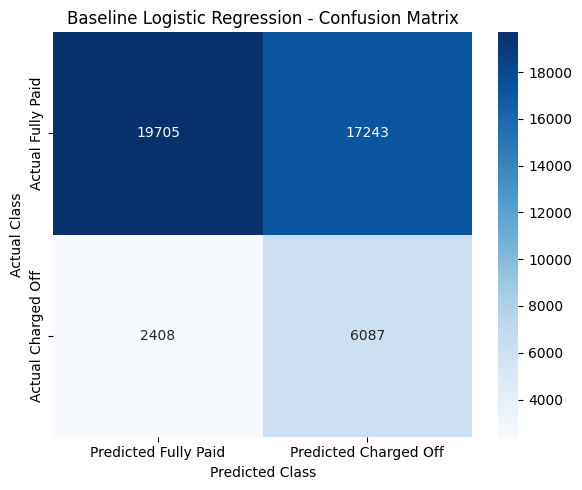

In [ ]:
# Confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Fully Paid",
        "Predicted Charged Off"
    ],
    yticklabels=[
        "Actual Fully Paid",
        "Actual Charged Off"
    ]
)

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

## 22. Baseline Model Interpretation

The baseline Logistic Regression model provides an initial reference point for the project.

Its performance will be compared against more advanced ensemble algorithms in later phases.

The baseline results should not be interpreted as the final performance of the project.

Instead, they establish a benchmark that future models should be evaluated against.

In Week 5, additional preprocessing, exploratory data analysis, feature engineering, and initial experiments with ensemble models will be performed.

# 23. Proposed Machine Learning Workflow

The complete project will follow the workflow below:

1. Load the LendingClub dataset.
2. Understand the dataset structure.
3. Define the binary default target.
4. Remove variables that create target leakage.
5. Perform data-quality checks.
6. Analyze missing values.
7. Perform exploratory data analysis.
8. Engineer useful features.
9. Split the dataset into training and testing sets.
10. Build preprocessing pipelines.
11. Establish a baseline model.
12. Train multiple ensemble models.
13. Compare model performance.
14. Perform hyperparameter tuning.
15. Evaluate tuned models.
16. Interpret model predictions and feature importance.
17. Draw conclusions and discuss limitations.

# 24. Planned Models

The following machine learning algorithms will be evaluated during the project.

## 1. Random Forest

Random Forest is an ensemble method that constructs multiple decision trees and combines their predictions.

It can model nonlinear relationships and interactions between borrower and loan characteristics.

## 2. Gradient Boosting

Gradient Boosting builds decision trees sequentially, with each subsequent model attempting to improve the errors made by previous models.

## 3. AdaBoost

AdaBoost combines multiple weak learners by assigning greater importance to observations that were previously misclassified.

## 4. XGBoost

XGBoost is a gradient boosting implementation designed for efficient and high-performance tree-based learning.

## 5. LightGBM

LightGBM is another gradient boosting framework designed to provide efficient training, particularly on larger datasets.

The performance of all five models will be compared using consistent evaluation metrics.

# 25. Hyperparameter Tuning Strategy

Hyperparameter tuning will be performed during the later stages of the project.

The goal is to identify parameter configurations that improve model performance while avoiding unnecessary model complexity.

### Random Forest

Potential parameters:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `max_features`

### Gradient Boosting

Potential parameters:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `subsample`

### AdaBoost

Potential parameters:

- `n_estimators`
- `learning_rate`

### XGBoost

Potential parameters:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `min_child_weight`
- `subsample`
- `colsample_bytree`
- `reg_alpha`
- `reg_lambda`

### LightGBM

Potential parameters:

- `n_estimators`
- `learning_rate`
- `num_leaves`
- `max_depth`
- `min_child_samples`
- `subsample`
- `colsample_bytree`
- `reg_alpha`
- `reg_lambda`

Randomized search and cross-validation will be considered to explore the hyperparameter space efficiently.

# 26. Model Evaluation Strategy

The primary evaluation metrics will be:

1. ROC-AUC
2. PR-AUC
3. Recall
4. Precision
5. F1-Score
6. Accuracy

ROC-AUC will be used to evaluate the overall discrimination ability of the models.

PR-AUC will also be emphasized because the default class may be less frequent than the non-default class.

Recall will receive particular attention because failing to identify an actual default represents a potentially important credit-risk error.

The confusion matrix will also be examined to understand the trade-off between false positives and false negatives.

No single metric will be used in isolation. Model performance will be evaluated using a combination of discrimination, class-level performance, and error analysis.

# 27. Planned Model Comparison

The final model comparison will use a table similar to the following:

| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC | PR-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | | | | | | |
| Random Forest | | | | | | |
| Gradient Boosting | | | | | | |
| AdaBoost | | | | | | |
| XGBoost | | | | | | |
| LightGBM | | | | | | |

The actual values will be generated from the experiments rather than predetermined.

The final phase will also include:

- ROC curves
- Precision-Recall curves
- Confusion matrices
- Feature importance
- Model interpretation
- Hyperparameter tuning results

## 28. Data Quality Assessment

Before performing exploratory analysis and model development, the dataset is examined for:

- Missing values
- Duplicate records
- Incorrect data types
- Constant or near-constant variables
- Potentially invalid numerical values
- High-cardinality categorical variables

This step is important because poor data quality can negatively affect both model training and interpretation.

In [ ]:
# Create a working copy for Week 5

week5_df = model_df.copy()

print("Dataset shape:")
print(week5_df.shape)

print("\nNumber of duplicate rows:")
print(week5_df.duplicated().sum())

Dataset shape:
(227214, 76)

Number of duplicate rows:
0


In [ ]:
# Display duplicate percentage

duplicate_count = week5_df.duplicated().sum()
duplicate_percentage = duplicate_count / len(week5_df) * 100

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

Duplicate rows: 0
Duplicate percentage: 0.0000%


### Duplicate Handling

Duplicate observations can cause certain records to receive excessive influence during model training.

If exact duplicate rows are present, they will be removed.

The removal is performed before model training while preserving the target distribution as much as possible.

In [ ]:
# Remove exact duplicate rows

before_duplicates = len(week5_df)

week5_df = week5_df.drop_duplicates().copy()

after_duplicates = len(week5_df)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Rows removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 227214
Rows after removing duplicates: 227214
Rows removed: 0


## 29. Missing-Value Analysis

Missing values are common in real-world financial datasets.

For example, variables related to previous delinquencies or joint applications may be unavailable for a large proportion of borrowers.

Instead of automatically removing columns with missing values, the project will investigate the extent and nature of missingness.

For the machine learning models, missing numerical values will initially be imputed using the median, while categorical variables will use the most frequent category.

More detailed missing-value treatment can be considered in Week 9.

In [ ]:
# Calculate missing-value statistics

missing_summary = pd.DataFrame({
    "Missing Count": week5_df.isna().sum(),
    "Missing Percentage": week5_df.isna().mean() * 100
})

missing_summary = (
    missing_summary
    .sort_values("Missing Percentage", ascending=False)
)

display(missing_summary.head(30))

,Missing Count,Missing Percentage
inq_fi,227214,100.000000
all_util,227214,100.000000
max_bal_bc,227214,100.000000
open_rv_24m,227214,100.000000
open_rv_12m,227214,100.000000
il_util,227214,100.000000
total_bal_il,227214,100.000000
mths_since_rcnt_il,227214,100.000000
open_il_24m,227214,100.000000
open_il_12m,227214,100.000000


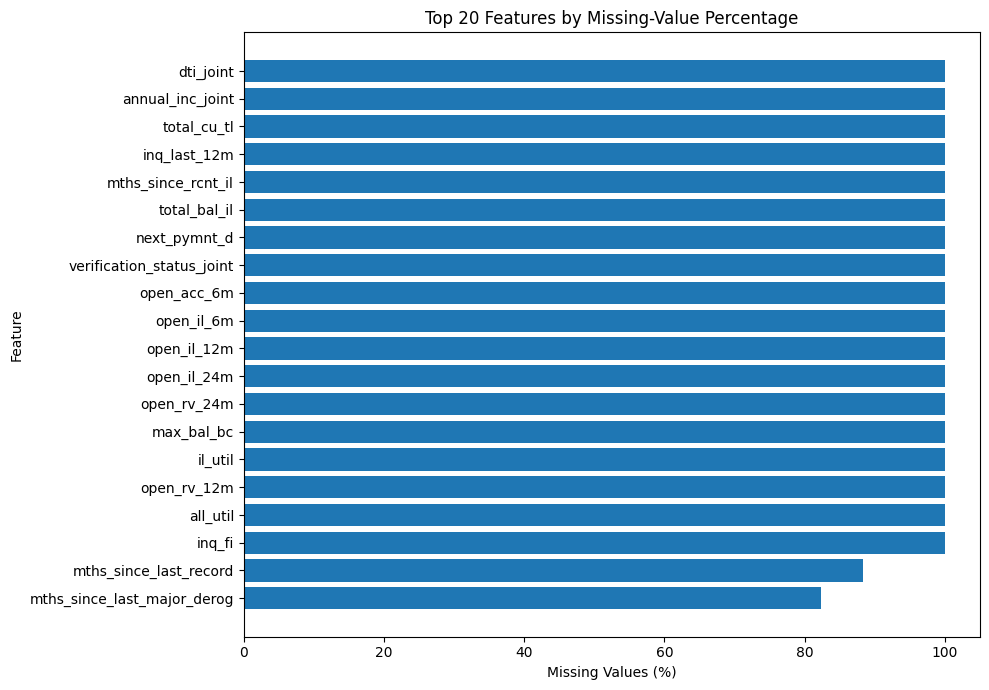

In [ ]:
# Plot the 20 variables with the highest percentage of missing values

top_missing = missing_summary.head(20).sort_values(
    "Missing Percentage"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_missing.index,
    top_missing["Missing Percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Top 20 Features by Missing-Value Percentage")

plt.tight_layout()
plt.show()

## 30. Target Variable Distribution

The target variable is examined to determine whether the dataset is balanced or imbalanced.

This is important because a strong imbalance between default and non-default observations can make accuracy misleading.

For credit-risk prediction, metrics such as Recall, F1-Score, ROC-AUC, and PR-AUC are therefore considered alongside accuracy.

In [ ]:
# Target distribution

target_counts = week5_df["default"].value_counts().sort_index()

target_percentages = (
    week5_df["default"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary.index = [
    "Fully Paid (0)",
    "Charged Off (1)"
]

display(target_summary)

,Count,Percentage
Fully Paid (0),184739,81.30617
Charged Off (1),42475,18.69383


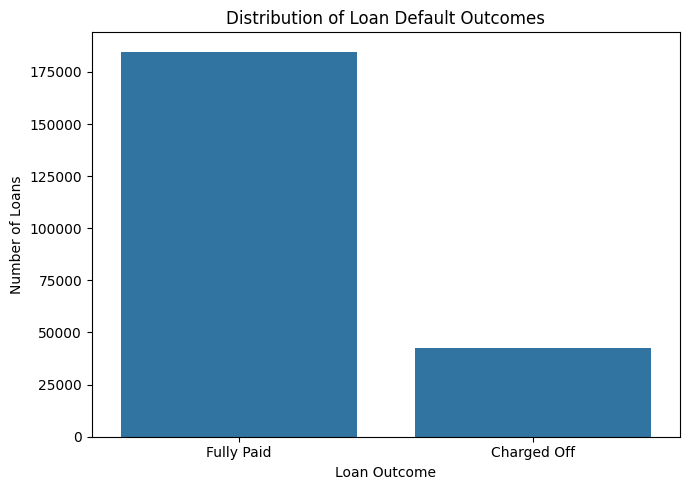

In [ ]:
# Visualize target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=week5_df,
    x="default"
)

plt.xticks(
    [0, 1],
    ["Fully Paid", "Charged Off"]
)

plt.xlabel("Loan Outcome")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Default Outcomes")

plt.tight_layout()
plt.show()

## 31. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand relationships between borrower characteristics, loan characteristics, and the default outcome.

The analysis focuses on variables that are potentially relevant to credit risk.

The EDA is descriptive and does not imply that an observed association represents a causal relationship.

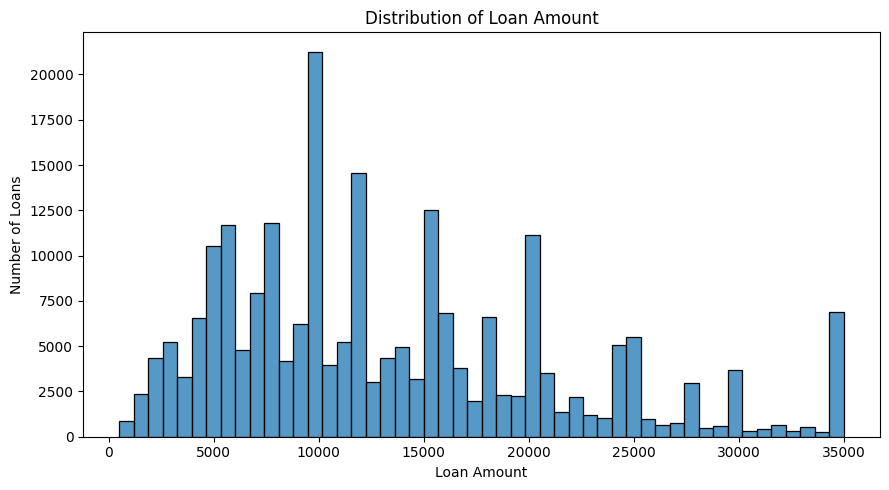

In [ ]:
# Loan amount distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=week5_df,
    x="loan_amnt",
    bins=50
)

plt.xlabel("Loan Amount")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Amount")

plt.tight_layout()
plt.show()

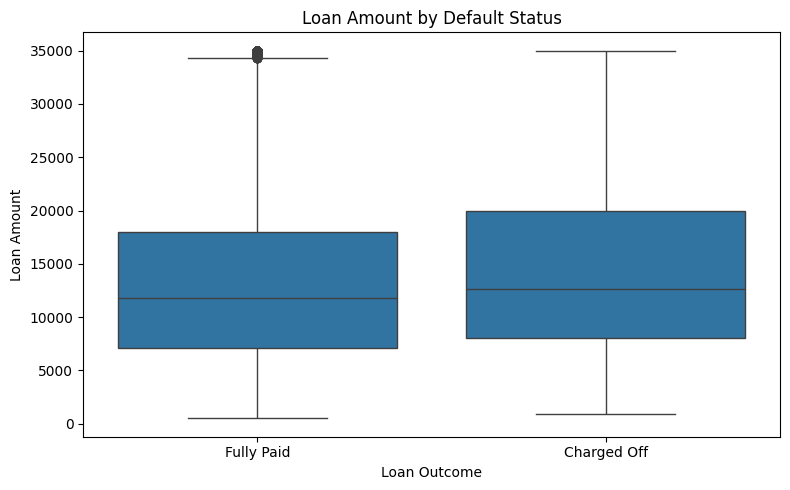

In [ ]:
# Loan amount by default status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=week5_df,
    x="default",
    y="loan_amnt"
)

plt.xticks(
    [0, 1],
    ["Fully Paid", "Charged Off"]
)

plt.xlabel("Loan Outcome")
plt.ylabel("Loan Amount")
plt.title("Loan Amount by Default Status")

plt.tight_layout()
plt.show()

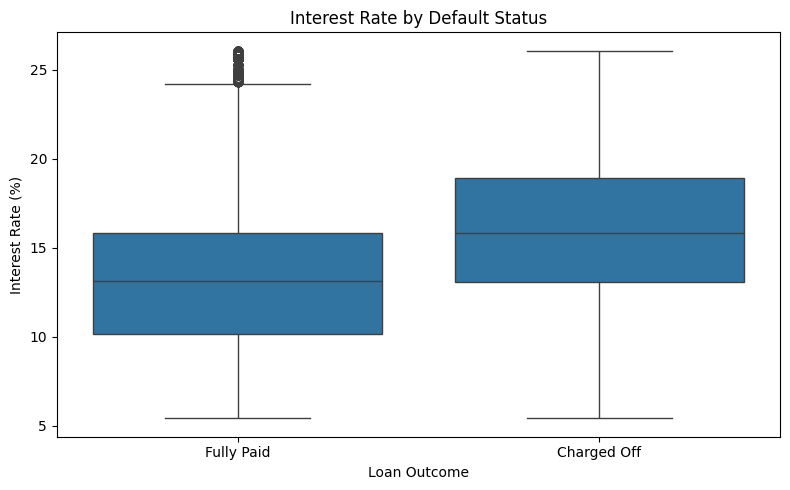

In [ ]:
# Interest rate by default status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=week5_df,
    x="default",
    y="int_rate"
)

plt.xticks(
    [0, 1],
    ["Fully Paid", "Charged Off"]
)

plt.xlabel("Loan Outcome")
plt.ylabel("Interest Rate (%)")
plt.title("Interest Rate by Default Status")

plt.tight_layout()
plt.show()

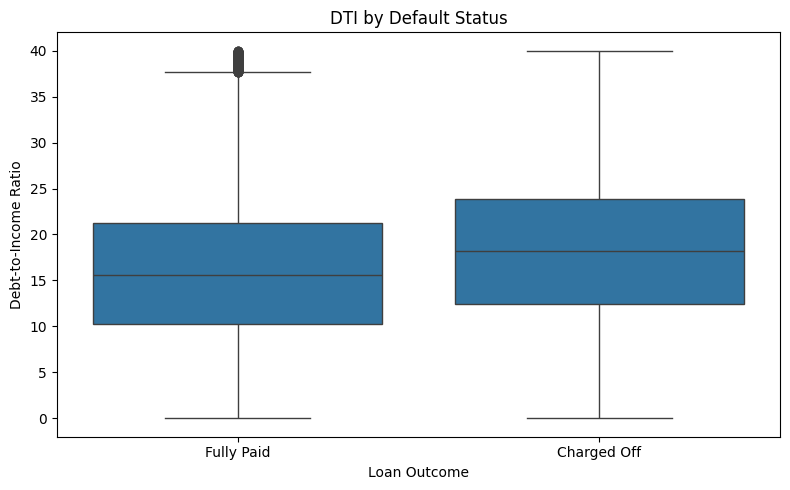

In [ ]:
# Debt-to-income ratio

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=week5_df,
    x="default",
    y="dti"
)

plt.xticks(
    [0, 1],
    ["Fully Paid", "Charged Off"]
)

plt.xlabel("Loan Outcome")
plt.ylabel("Debt-to-Income Ratio")
plt.title("DTI by Default Status")

plt.tight_layout()
plt.show()

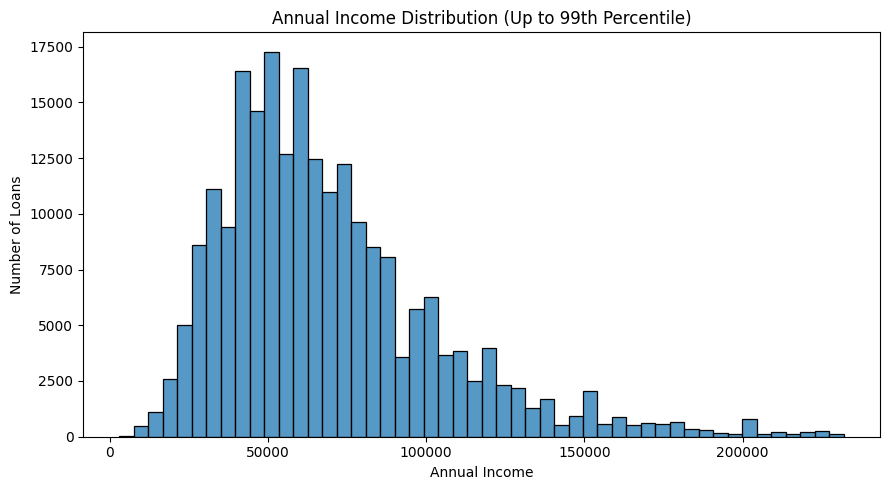

In [ ]:
# Annual income distribution

income_cap = week5_df["annual_inc"].quantile(0.99)

plt.figure(figsize=(9, 5))

sns.histplot(
    data=week5_df[
        week5_df["annual_inc"] <= income_cap
    ],
    x="annual_inc",
    bins=50
)

plt.xlabel("Annual Income")
plt.ylabel("Number of Loans")
plt.title("Annual Income Distribution (Up to 99th Percentile)")

plt.tight_layout()
plt.show()

### Loan Grade and Default Rate

LendingClub assigns grades and sub-grades to loans.

The relationship between loan grade and observed default rate will be examined to understand whether default rates differ across risk categories.

This analysis is descriptive and does not imply that grade itself causes default.

In [ ]:
# Calculate default rate by grade

grade_default = (
    week5_df
    .groupby("grade")["default"]
    .agg(["mean", "count"])
    .sort_index()
)

grade_default["default_rate_percent"] = (
    grade_default["mean"] * 100
)

display(grade_default)

,mean,count,default_rate_percent
grade,,,
A,0.064825,38982,6.482479
B,0.130592,70119,13.059228
C,0.206464,57739,20.646357
D,0.272009,35837,27.200938
E,0.350759,16279,35.075865
F,0.406080,6612,40.607985
G,0.441677,1646,44.167679


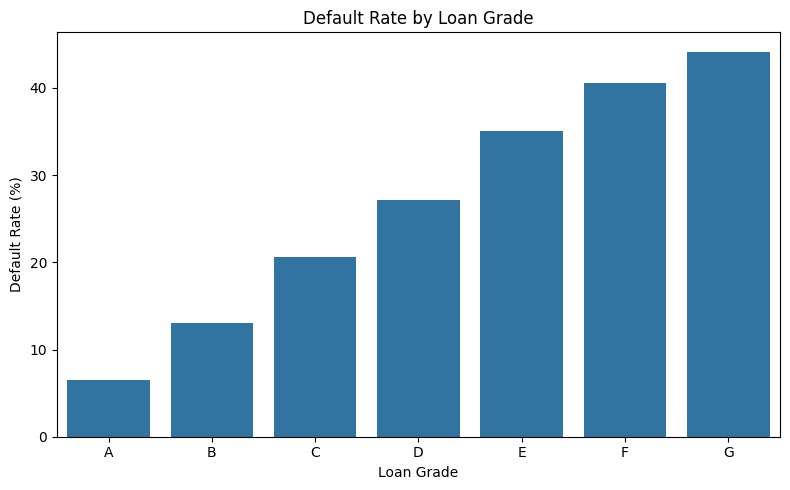

In [ ]:
# Plot default rate by grade

plt.figure(figsize=(8, 5))

sns.barplot(
    data=grade_default.reset_index(),
    x="grade",
    y="default_rate_percent"
)

plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Grade")

plt.tight_layout()
plt.show()

In [ ]:
# Default rate by loan term

term_default = (
    week5_df
    .groupby("term")["default"]
    .agg(["mean", "count"])
)

term_default["default_rate_percent"] = (
    term_default["mean"] * 100
)

display(term_default)

,mean,count,default_rate_percent
term,,,
36 months,0.153761,178556,15.376128
60 months,0.308685,48658,30.868511


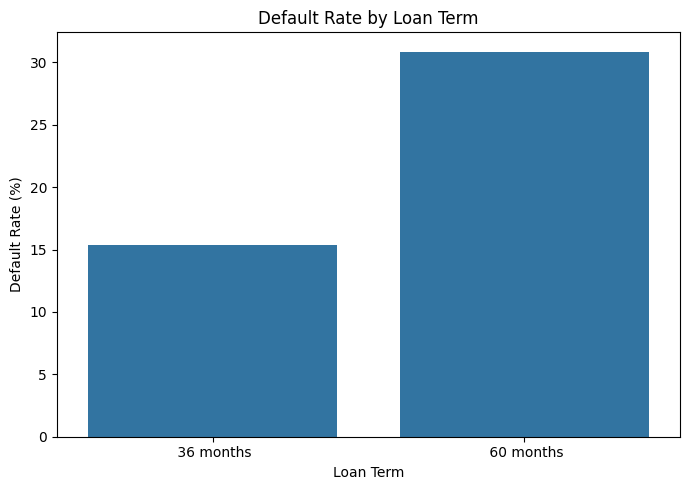

In [ ]:
# Plot default rate by loan term

plt.figure(figsize=(7, 5))

sns.barplot(
    data=term_default.reset_index(),
    x="term",
    y="default_rate_percent"
)

plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Loan Term")

plt.tight_layout()
plt.show()

In [ ]:
# Default rate by home ownership

home_default = (
    week5_df
    .groupby("home_ownership")["default"]
    .agg(["mean", "count"])
)

home_default["default_rate_percent"] = (
    home_default["mean"] * 100
)

display(
    home_default.sort_values(
        "default_rate_percent",
        ascending=False
    )
)

,mean,count,default_rate_percent
home_ownership,,,
RENT,0.207503,95931,20.750331
OWN,0.195828,19078,19.582765
OTHER,0.191489,141,19.148936
MORTGAGE,0.167818,112020,16.781825
NONE,0.162791,43,16.279070
ANY,0.000000,1,0.000000


In [ ]:
# Default rate by verification status

verification_default = (
    week5_df
    .groupby("verification_status")["default"]
    .agg(["mean", "count"])
)

verification_default["default_rate_percent"] = (
    verification_default["mean"] * 100
)

display(verification_default)

,mean,count,default_rate_percent
verification_status,,,
Not Verified,0.146922,79117,14.692165
Source Verified,0.198317,63333,19.831683
Verified,0.215787,84764,21.578736


In [ ]:
# Important numerical credit variables

credit_variables = [
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc"
]

available_credit_variables = [
    col for col in credit_variables
    if col in week5_df.columns
]

# Correlation with target

credit_target_corr = (
    week5_df[
        available_credit_variables + ["default"]
    ]
    .corr(numeric_only=True)["default"]
    .drop("default")
    .sort_values()
)

display(credit_target_corr.to_frame("Correlation with Default"))

,Correlation with Default
total_acc,-0.027756
revol_bal,-0.004529
pub_rec,0.007109
open_acc,0.016649
delinq_2yrs,0.018993
inq_last_6mths,0.056276
revol_util,0.093949
dti,0.115997


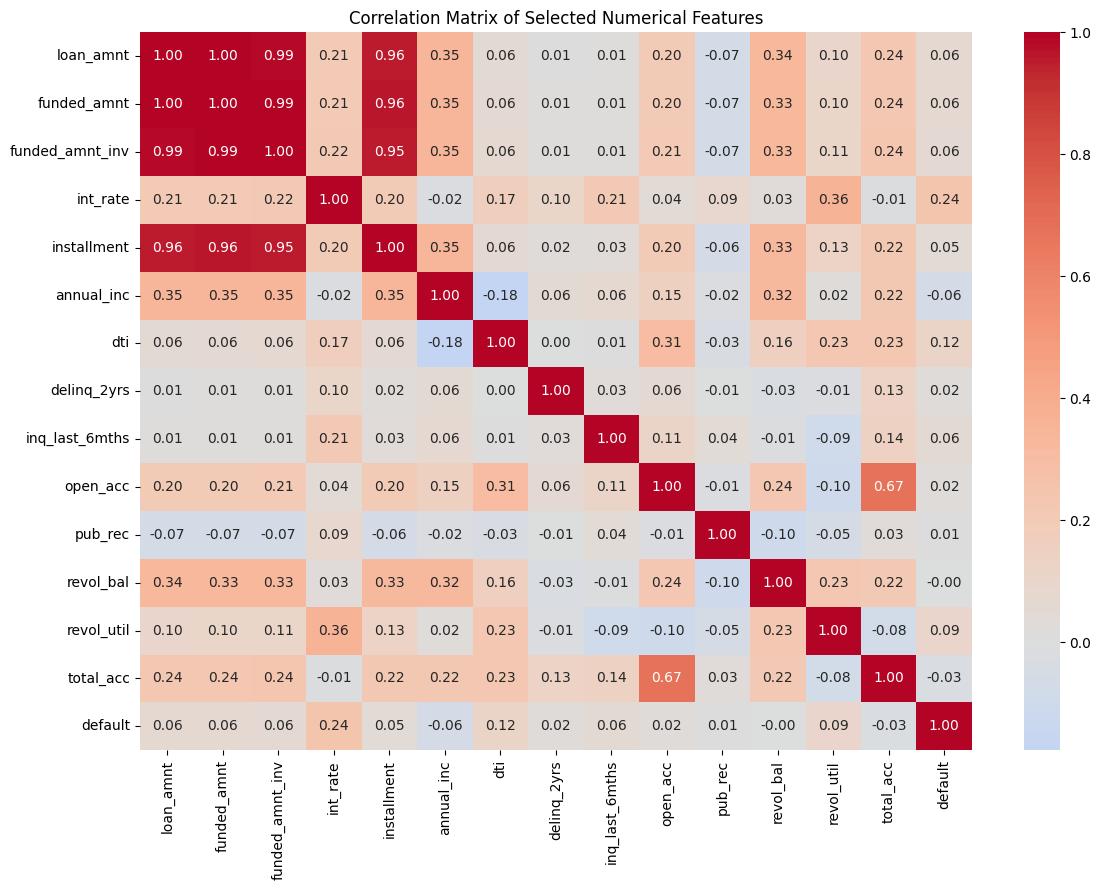

In [ ]:
# Correlation matrix for selected numerical variables

correlation_features = [
    "loan_amnt",
    "funded_amnt",
    "funded_amnt_inv",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "default"
]

available_correlation_features = [
    col for col in correlation_features
    if col in week5_df.columns
]

corr_matrix = week5_df[
    available_correlation_features
].corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Selected Numerical Features")

plt.tight_layout()
plt.show()

## 32. Initial EDA Findings

The exploratory analysis provides several observations that will guide the subsequent modelling process.

### Target Variable

The target distribution should be examined for class imbalance. Because the default class may represent a smaller proportion of observations, accuracy alone is not sufficient for evaluating the models.

### Interest Rate

Interest rate distributions can differ between default and non-default groups. This variable is therefore retained as an important predictive feature.

### Loan Grade

The observed default rate varies across loan grades. Grade and sub-grade will be considered as categorical predictors.

### Debt-to-Income Ratio

DTI provides information about the borrower's debt burden relative to income and is therefore relevant to credit-risk modelling.

### Credit History Variables

Variables such as delinquency history, revolving utilization, number of open accounts, public records, and total accounts provide information about the borrower's historical credit profile.

### Income

Annual income is potentially important for assessing repayment capacity. Because income can be highly skewed, a log-transformed version will be considered during feature engineering.

These observations are exploratory and should not be interpreted as causal relationships.

# 33. Initial Feature Engineering

Feature engineering is performed to create additional variables that may provide more useful representations of borrower and loan characteristics.

The following features will initially be considered:

1. Numerical representation of loan term
2. Numerical representation of employment length
3. Credit history length
4. Log-transformed annual income
5. Loan amount to annual income ratio
6. Installment to annual income ratio
7. Total funded amount to annual income ratio
8. Issue year
9. Issue month

These features are constructed using information available at or around loan origination.

No post-origination repayment variables are used.

In [ ]:
def create_features(data):
    """
    Create initial engineered features for the LendingClub dataset.

    The function only uses information that is intended to be
    available at or around loan origination.
    """

    data = data.copy()

    # ---------------------------------------------------------
    # 1. Loan term
    # ---------------------------------------------------------
    if "term" in data.columns:
        data["term_num"] = (
            data["term"]
            .astype(str)
            .str.extract(r"(\d+)", expand=False)
            .astype(float)
        )

    # ---------------------------------------------------------
    # 2. Employment length
    # ---------------------------------------------------------
    if "emp_length" in data.columns:

        emp_map = {
            "< 1 year": 0.5,
            "1 year": 1,
            "2 years": 2,
            "3 years": 3,
            "4 years": 4,
            "5 years": 5,
            "6 years": 6,
            "7 years": 7,
            "8 years": 8,
            "9 years": 9,
            "10+ years": 10
        }

        data["emp_length_num"] = (
            data["emp_length"]
            .map(emp_map)
        )

    # ---------------------------------------------------------
    # 3. Issue date features
    # ---------------------------------------------------------
    if "issue_d" in data.columns:

        issue_date = pd.to_datetime(
            data["issue_d"],
            format="%b-%Y",
            errors="coerce"
        )

        data["issue_year"] = issue_date.dt.year
        data["issue_month"] = issue_date.dt.month

    # ---------------------------------------------------------
    # 4. Credit history length
    # ---------------------------------------------------------
    if (
        "earliest_cr_line" in data.columns
        and "issue_d" in data.columns
    ):

        earliest_credit = pd.to_datetime(
            data["earliest_cr_line"],
            format="%b-%Y",
            errors="coerce"
        )

        issue_date = pd.to_datetime(
            data["issue_d"],
            format="%b-%Y",
            errors="coerce"
        )

        data["credit_history_years"] = (
            (issue_date - earliest_credit)
            .dt.days / 365.25
        )

        # Avoid impossible negative values
        data.loc[
            data["credit_history_years"] < 0,
            "credit_history_years"
        ] = np.nan

    # ---------------------------------------------------------
    # 5. Log annual income
    # ---------------------------------------------------------
    if "annual_inc" in data.columns:

        data["log_annual_inc"] = np.log1p(
            data["annual_inc"].clip(lower=0)
        )

    # ---------------------------------------------------------
    # 6. Loan amount / income ratio
    # ---------------------------------------------------------
    if (
        "loan_amnt" in data.columns
        and "annual_inc" in data.columns
    ):

        data["loan_income_ratio"] = (
            data["loan_amnt"] /
            data["annual_inc"].replace(0, np.nan)
        )

    # ---------------------------------------------------------
    # 7. Installment / income ratio
    # ---------------------------------------------------------
    if (
        "installment" in data.columns
        and "annual_inc" in data.columns
    ):

        data["installment_income_ratio"] = (
            (data["installment"] * 12) /
            data["annual_inc"].replace(0, np.nan)
        )

    # ---------------------------------------------------------
    # 8. Funded amount / income ratio
    # ---------------------------------------------------------
    if (
        "funded_amnt" in data.columns
        and "annual_inc" in data.columns
    ):

        data["funded_income_ratio"] = (
            data["funded_amnt"] /
            data["annual_inc"].replace(0, np.nan)
        )

    return data

In [ ]:
# Apply feature engineering

engineered_df = create_features(week5_df)

print("Original number of columns:", week5_df.shape[1])
print("New number of columns:", engineered_df.shape[1])

new_features = [
    col for col in engineered_df.columns
    if col not in week5_df.columns
]

print("\nNewly created features:")
for feature in new_features:
    print("-", feature)

Original number of columns: 76
New number of columns: 85

Newly created features:
- term_num
- emp_length_num
- issue_year
- issue_month
- credit_history_years
- log_annual_inc
- loan_income_ratio
- installment_income_ratio
- funded_income_ratio


In [ ]:
# Display engineered features

engineered_display = [
    col for col in new_features
    if col in engineered_df.columns
]

display(
    engineered_df[
        engineered_display
    ].head()
)

,term_num,emp_length_num,issue_year,issue_month,credit_history_years,log_annual_inc,loan_income_ratio,installment_income_ratio,funded_income_ratio
0,36.0,10.0,NaN,NaN,NaN,10.085851,0.208333,0.081435,0.208333
1,60.0,0.5,NaN,NaN,NaN,10.308986,0.083333,0.023932,0.083333
2,36.0,10.0,NaN,NaN,NaN,9.413526,0.195886,0.082595,0.195886
3,36.0,10.0,NaN,NaN,NaN,10.803669,0.203252,0.082759,0.203252
5,36.0,3.0,NaN,NaN,NaN,10.491302,0.138889,0.052153,0.138889


### Handling Invalid Derived Values

Ratio-based features can generate infinite values when the denominator is zero.

Such values are converted to missing values and will subsequently be handled by the preprocessing pipeline.

In [ ]:
# Replace infinite values with NaN

engineered_df = engineered_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinite values remaining:")
print(
    np.isinf(
        engineered_df.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

Infinite values remaining:
0


## 34. Modelling Dataset

The engineered dataset will now be prepared for machine learning.

Variables that represent identifiers, text descriptions, URLs, and post-origination information are excluded.

High-cardinality text variables such as `emp_title`, `desc`, and `title` are not included in the initial tree-based modelling experiment.

They may be investigated separately in future work, but including them directly would substantially increase preprocessing complexity and dimensionality.

In [ ]:
# Columns to exclude from Week 5 modelling

week5_excluded = [
    # Target / leakage
    "default",
    "loan_status",

    # Identifiers
    "id",
    "member_id",
    "url",

    # Post-origination variables
    "out_prncp",
    "out_prncp_inv",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",
    "recoveries",
    "collection_recovery_fee",
    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",

    # High-cardinality text
    "emp_title",
    "desc",
    "title",

    # Very high-cardinality / granular location
    "zip_code"
]

week5_excluded = [
    col for col in week5_excluded
    if col in engineered_df.columns
]

week5_features = [
    col for col in engineered_df.columns
    if col not in week5_excluded
]

print("Number of Week 5 features:", len(week5_features))

print("\nExcluded columns:")
for col in week5_excluded:
    print("-", col)

Number of Week 5 features: 63

Excluded columns:
- default
- loan_status
- id
- member_id
- url
- out_prncp
- out_prncp_inv
- total_pymnt
- total_pymnt_inv
- total_rec_prncp
- total_rec_int
- total_rec_late_fee
- recoveries
- collection_recovery_fee
- last_pymnt_d
- last_pymnt_amnt
- next_pymnt_d
- last_credit_pull_d
- emp_title
- desc
- title
- zip_code


## 35. Train-Test Split

A fresh stratified train-test split is created for the Week 5 modelling experiments.

The same random seed is used to maintain reproducibility.

The test set remains untouched during preliminary model tuning. Cross-validation within the training set will be used for model selection and hyperparameter tuning.

In [ ]:
# Prepare X and y

X_week5 = engineered_df[week5_features].copy()
y_week5 = engineered_df["default"].copy()

# Train-test split

X_train5, X_test5, y_train5, y_test5 = train_test_split(
    X_week5,
    y_week5,
    test_size=0.20,
    stratify=y_week5,
    random_state=RANDOM_STATE
)

print("Training set:", X_train5.shape)
print("Testing set:", X_test5.shape)

Training set: (181771, 63)
Testing set: (45443, 63)


In [ ]:
# Identify data types

numeric_features5 = X_train5.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features5 = X_train5.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features5))
print("Number of categorical features:", len(categorical_features5))

Number of numerical features: 50
Number of categorical features: 13


In [ ]:
# Preprocessing pipeline

numeric_transformer5 = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer5 = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor5 = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer5,
            numeric_features5
        ),
        (
            "cat",
            categorical_transformer5,
            categorical_features5
        )
    ]
)

## 36. Machine Learning Libraries

The experiments include:

- Random Forest
- Gradient Boosting
- AdaBoost
- XGBoost
- LightGBM

XGBoost and LightGBM are external gradient-boosting libraries and may not be pre-installed in every notebook environment.

In [ ]:
# Install XGBoost and LightGBM if required

!pip install -q xgboost lightgbm

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

## 37. Model Evaluation Function

To ensure that all models are evaluated consistently, a reusable evaluation function is created.

The function reports:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

This allows the models to be compared using the same evaluation framework.

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a binary classification model.
    """

    # Class predictions
    predictions = model.predict(X_test)

    # Probability predictions
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_test,
            probabilities
        )
    }

    return results

## 38. Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees.

It is useful for this problem because:

- It can model nonlinear relationships.
- It can capture interactions between variables.
- It can work with mixed feature types after preprocessing.
- It provides feature-importance measures.
- It is relatively robust to outliers and nonlinear patterns.

A preliminary configuration is used at this stage. Hyperparameter tuning will be performed later.

In [ ]:
# Random Forest configuration

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor5
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=15,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train5,
    y_train5
)

print("Random Forest training completed.")

Random Forest training completed.


## 39. Gradient Boosting

Gradient Boosting builds decision trees sequentially.

Each new tree attempts to improve the predictions produced by the existing ensemble.

The preliminary model is used to establish an initial benchmark before hyperparameter tuning.

In [ ]:
# Gradient Boosting

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("classifier", GradientBoostingClassifier(
            n_estimators=75,
            learning_rate=0.05,
            max_depth=2,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE
        ))
    ]
)

gb_model.fit(X_train5, y_train5)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


## 40. AdaBoost

AdaBoost combines multiple weak learners into an ensemble.

The algorithm places additional emphasis on observations that are difficult to classify correctly.

A preliminary AdaBoost model is trained for comparison with the other ensemble approaches.

In [ ]:
ada_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor5
        ),
        (
            "classifier",
            AdaBoostClassifier(
                n_estimators=200,
                learning_rate=0.05,
                random_state=RANDOM_STATE
            )
        )
    ]
)

ada_model.fit(
    X_train5,
    y_train5
)

print("AdaBoost training completed.")

AdaBoost training completed.


## 41. XGBoost

XGBoost is a gradient boosting algorithm designed for efficient and regularized tree-based learning.

The preliminary configuration uses a moderate learning rate, tree depth, subsampling, and feature subsampling.

These parameters are starting values and are not treated as the final optimized configuration.

In [ ]:
# Calculate class imbalance ratio

negative_count = (y_train5 == 0).sum()
positive_count = (y_train5 == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative class:", negative_count)
print("Positive class:", positive_count)
print("Scale positive weight:", scale_pos_weight)

Negative class: 147791
Positive class: 33980
Scale positive weight: 4.3493525603296055


In [ ]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor5
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train5,
    y_train5
)

print("XGBoost training completed.")

XGBoost training completed.


## 42. LightGBM

LightGBM is a gradient boosting framework designed for efficient tree-based learning.

It is included because the dataset is relatively large and LightGBM can provide efficient training for large tabular datasets.

A preliminary configuration is used at this stage.

In [ ]:
lgbm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor5
        ),
        (
            "classifier",
            LGBMClassifier(
                n_estimators=200,
                learning_rate=0.05,
                num_leaves=31,
                max_depth=-1,
                subsample=0.8,
                colsample_bytree=0.8,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

lgbm_model.fit(
    X_train5,
    y_train5
)

print("LightGBM training completed.")

LightGBM training completed.


## 43. Initial Model Comparison

The five ensemble models are now evaluated on the same held-out test set.

The same evaluation metrics are used for every model to ensure a consistent comparison.

The test set is not used for hyperparameter selection at this stage.

In [ ]:
# Evaluate all initial models

models = {
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "AdaBoost": ada_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

results = []

for model_name, model in models.items():

    print(f"Evaluating {model_name}...")

    result = evaluate_model(
        model,
        X_test5,
        y_test5,
        model_name
    )

    results.append(result)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating AdaBoost...
Evaluating XGBoost...
Evaluating LightGBM...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.660102,0.308121,0.656975,0.419498,0.719536,0.365725
1,XGBoost,0.660564,0.307948,0.654032,0.418736,0.718536,0.367345
2,Random Forest,0.676980,0.312697,0.607652,0.412910,0.707107,0.349943
3,Gradient Boosting,0.813591,0.575949,0.010712,0.021033,0.704621,0.349782
4,AdaBoost,0.813063,0.000000,0.000000,0.000000,0.696308,0.338665


In [ ]:
# Evaluate the Week 2 Logistic Regression baseline
# on the Week 5 train/test split

baseline_week5 = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor5
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_week5.fit(
    X_train5,
    y_train5
)

baseline_result = evaluate_model(
    baseline_week5,
    X_test5,
    y_test5,
    "Logistic Regression"
)

# Add baseline to comparison
results_with_baseline = pd.concat(
    [
        pd.DataFrame([baseline_result]),
        results_df
    ],
    ignore_index=True
)

display(
    results_with_baseline.sort_values(
        "ROC-AUC",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.660102,0.308121,0.656975,0.419498,0.719536,0.365725
1,XGBoost,0.660564,0.307948,0.654032,0.418736,0.718536,0.367345
2,Random Forest,0.676980,0.312697,0.607652,0.412910,0.707107,0.349943
3,Gradient Boosting,0.813591,0.575949,0.010712,0.021033,0.704621,0.349782
4,AdaBoost,0.813063,0.000000,0.000000,0.000000,0.696308,0.338665
5,Logistic Regression,0.558106,0.249524,0.679341,0.364988,0.649421,0.293076


## 44. Visual Comparison of Model Performance

ROC-AUC and PR-AUC are visualized to compare the initial models.

ROC-AUC evaluates overall ranking/discrimination ability, while PR-AUC focuses more directly on the precision-recall trade-off for the default class.

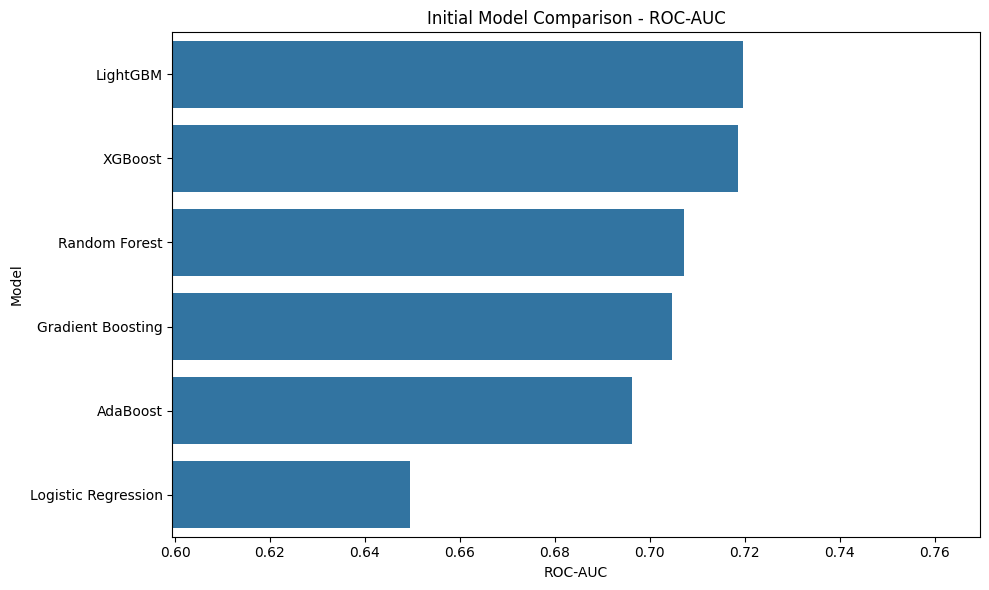

In [ ]:
# ROC-AUC comparison

plot_results = results_with_baseline.sort_values(
    "ROC-AUC",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_results,
    x="ROC-AUC",
    y="Model"
)

plt.xlabel("ROC-AUC")
plt.ylabel("Model")
plt.title("Initial Model Comparison - ROC-AUC")

plt.xlim(
    max(0, plot_results["ROC-AUC"].min() - 0.05),
    min(1, plot_results["ROC-AUC"].max() + 0.05)
)

plt.tight_layout()
plt.show()

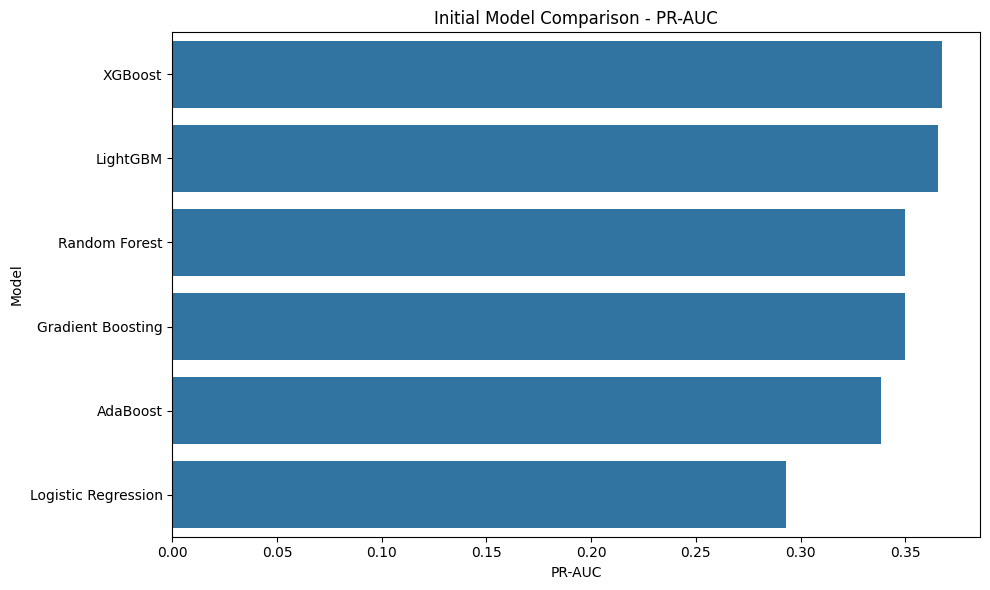

In [ ]:
# PR-AUC comparison

plot_results = results_with_baseline.sort_values(
    "PR-AUC",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_results,
    x="PR-AUC",
    y="Model"
)

plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.title("Initial Model Comparison - PR-AUC")

plt.tight_layout()
plt.show()

In [ ]:
# Display all metrics

comparison_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

display(
    results_with_baseline[
        comparison_columns
    ]
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.6601,0.3081,0.6570,0.4195,0.7195,0.3657
1,XGBoost,0.6606,0.3079,0.6540,0.4187,0.7185,0.3673
2,Random Forest,0.6770,0.3127,0.6077,0.4129,0.7071,0.3499
3,Gradient Boosting,0.8136,0.5759,0.0107,0.0210,0.7046,0.3498
4,AdaBoost,0.8131,0.0000,0.0000,0.0000,0.6963,0.3387
5,Logistic Regression,0.5581,0.2495,0.6793,0.3650,0.6494,0.2931


## 45. Preliminary Model Comparison

The initial model comparison provides a first indication of how the different algorithms perform on the LendingClub default prediction problem.

The results should be interpreted across multiple metrics rather than relying on a single metric.

### ROC-AUC

ROC-AUC provides an overall measure of how well the models discriminate between default and non-default loans.

### PR-AUC

PR-AUC is particularly useful when the default class is less frequent because it focuses on precision and recall for the positive class.

### Recall

Recall measures the proportion of actual defaults that are detected by the model.

### Precision

Precision measures how many loans predicted as defaults are actually defaults.

### F1-Score

F1-Score combines precision and recall into a single metric.

The Week 5 results should therefore be considered preliminary because the models have not yet undergone comprehensive hyperparameter optimization.

The model rankings may change after tuning and after further feature engineering in Week 9.

## 46. Confusion Matrix Analysis

Confusion matrices are generated for the initial models to examine the types of classification errors.

The four outcomes are:

- True Negative: Fully Paid correctly identified
- False Positive: Fully Paid incorrectly classified as default
- False Negative: Default incorrectly classified as Fully Paid
- True Positive: Default correctly identified

False negatives are particularly important to monitor in a credit-risk context because they represent actual defaults that were not identified by the model.

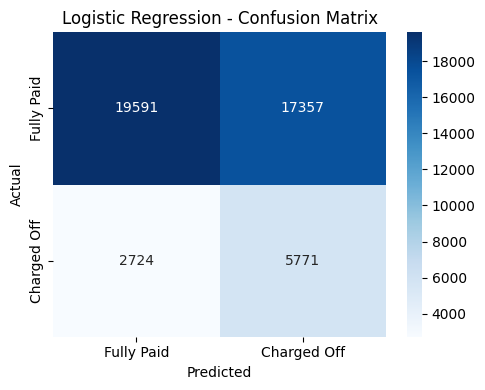

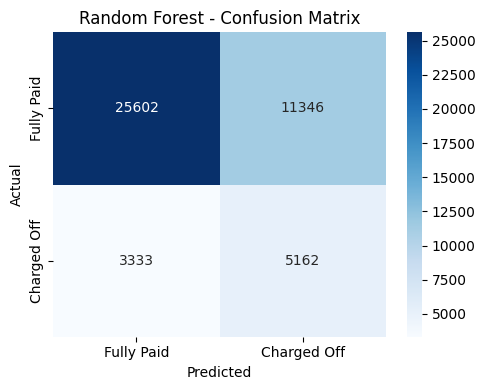

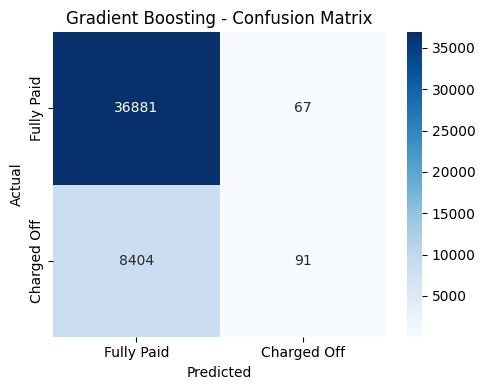

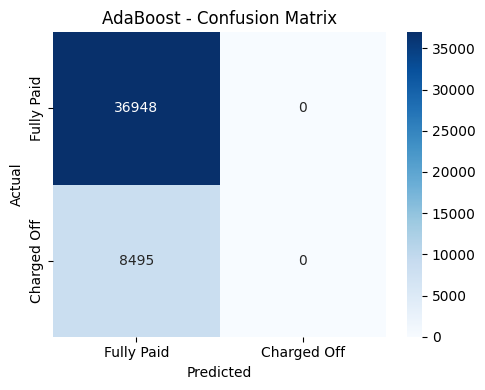

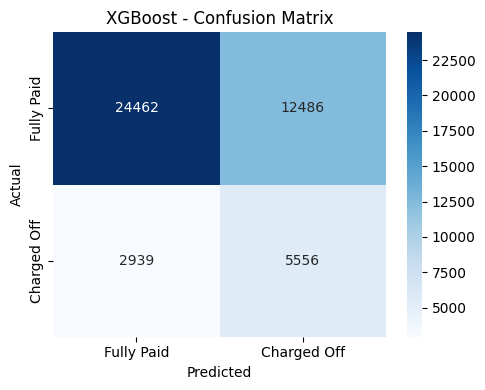

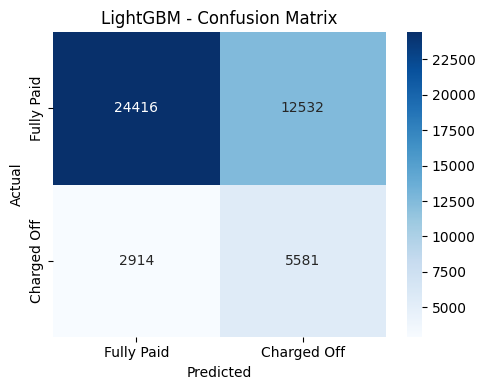

In [ ]:
# Generate confusion matrices for all initial models

for model_name, model in {
    "Logistic Regression": baseline_week5,
    **models
}.items():

    predictions = model.predict(X_test5)

    cm = confusion_matrix(
        y_test5,
        predictions
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Fully Paid",
            "Charged Off"
        ],
        yticklabels=[
            "Fully Paid",
            "Charged Off"
        ]
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

# 47. Preliminary Hyperparameter Tuning

The Week 5 phase includes limited hyperparameter tuning to investigate whether model performance can be improved over the initial configurations.

RandomizedSearchCV is used instead of an exhaustive grid search because the dataset is relatively large and the hyperparameter spaces can be substantial.

Three-fold cross-validation is used on the training set.

The test set remains separate and is used only for final evaluation after tuning.

ROC-AUC is selected as the optimization metric for the preliminary tuning stage.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# Random Forest preliminary tuning - FAST VERSION

rf_param_grid = {
    "classifier__n_estimators": [50, 75],
    "classifier__max_depth": [10, 15],
    "classifier__min_samples_split": [5],
    "classifier__min_samples_leaf": [2],
    "classifier__max_features": ["sqrt"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_grid,
    n_iter=2,                 # Only 2 combinations for Week 5
    scoring="roc_auc",
    cv=2,                     # 2-fold CV instead of 3
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train5, y_train5)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(rf_search.best_score_)

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Random Forest parameters:
{'classifier__n_estimators': 75, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 15}

Best cross-validation ROC-AUC:
0.7036839051251594


In [ ]:
# XGBoost preliminary tuning

xgb_param_grid = {
    "classifier__n_estimators": [150, 250, 350],
    "classifier__learning_rate": [0.03, 0.05, 0.10],
    "classifier__max_depth": [3, 5, 7],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train5,
    y_train5
)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost parameters:
{'classifier__subsample': 0.7, 'classifier__n_estimators': 350, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.7}

Best cross-validation ROC-AUC:
0.7149374962934063


In [ ]:
# LightGBM preliminary tuning

lgbm_param_grid = {
    "classifier__n_estimators": [150, 250, 350],
    "classifier__learning_rate": [0.03, 0.05, 0.10],
    "classifier__num_leaves": [15, 31, 63],
    "classifier__max_depth": [-1, 5, 10],
    "classifier__min_child_samples": [10, 20, 40],
    "classifier__subsample": [0.7, 0.8, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(
    X_train5,
    y_train5
)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(lgbm_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best LightGBM parameters:
{'classifier__subsample': 0.8, 'classifier__num_leaves': 63, 'classifier__n_estimators': 150, 'classifier__min_child_samples': 40, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}

Best cross-validation ROC-AUC:
0.7158305196996021


# 48. Preliminary Tuned Model Evaluation

The best models identified by cross-validation are now evaluated on the held-out test set.

The test set has not been used to select the hyperparameters.

This provides an initial estimate of how the tuned models generalize to unseen observations.

In [ ]:
# Evaluate tuned models

tuned_models = {
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned XGBoost": xgb_search.best_estimator_,
    "Tuned LightGBM": lgbm_search.best_estimator_
}

tuned_results = []

for model_name, model in tuned_models.items():

    print(f"Evaluating {model_name}...")

    result = evaluate_model(
        model,
        X_test5,
        y_test5,
        model_name
    )

    tuned_results.append(result)

tuned_results_df = pd.DataFrame(
    tuned_results
)

display(
    tuned_results_df
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
    .round(4)
)

Evaluating Tuned Random Forest...
Evaluating Tuned XGBoost...
Evaluating Tuned LightGBM...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.6720,0.3136,0.6347,0.4198,0.7210,0.3695
1,Tuned LightGBM,0.6655,0.3112,0.6506,0.4210,0.7205,0.3680
2,Tuned Random Forest,0.6783,0.3134,0.6054,0.4130,0.7066,0.3495


# 49. Complete Week 5 Model Comparison

The final Week 5 comparison combines:

- Logistic Regression baseline
- Initial Random Forest
- Initial Gradient Boosting
- Initial AdaBoost
- Initial XGBoost
- Initial LightGBM
- Tuned Random Forest
- Tuned XGBoost
- Tuned LightGBM

This provides a preliminary view of the effect of model selection and hyperparameter tuning.

The final model selection will not be made solely from these Week 5 results. Additional feature engineering, tuning, temporal validation, and model interpretation will be performed during Week 9.

In [ ]:
# Combine initial and tuned model results

all_week5_results = pd.concat(
    [
        results_with_baseline,
        tuned_results_df
    ],
    ignore_index=True
)

# Remove duplicate model names if necessary
all_week5_results = (
    all_week5_results
    .drop_duplicates(subset=["Model"])
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    all_week5_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Tuned XGBoost,0.6720,0.3136,0.6347,0.4198,0.7210,0.3695
1,Tuned LightGBM,0.6655,0.3112,0.6506,0.4210,0.7205,0.3680
2,LightGBM,0.6601,0.3081,0.6570,0.4195,0.7195,0.3657
3,XGBoost,0.6606,0.3079,0.6540,0.4187,0.7185,0.3673
4,Random Forest,0.6770,0.3127,0.6077,0.4129,0.7071,0.3499
5,Tuned Random Forest,0.6783,0.3134,0.6054,0.4130,0.7066,0.3495
6,Gradient Boosting,0.8136,0.5759,0.0107,0.0210,0.7046,0.3498
7,AdaBoost,0.8131,0.0000,0.0000,0.0000,0.6963,0.3387
8,Logistic Regression,0.5581,0.2495,0.6793,0.3650,0.6494,0.2931


In [ ]:
# Compare initial and tuned versions of selected models

tuning_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Initial ROC-AUC": [
        results_df.loc[
            results_df["Model"] == "Random Forest",
            "ROC-AUC"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "XGBoost",
            "ROC-AUC"
        ].iloc[0],

        results_df.loc[
            results_df["Model"] == "LightGBM",
            "ROC-AUC"
        ].iloc[0]
    ],

    "Tuned ROC-AUC": [
        tuned_results_df.loc[
            tuned_results_df["Model"] == "Tuned Random Forest",
            "ROC-AUC"
        ].iloc[0],

        tuned_results_df.loc[
            tuned_results_df["Model"] == "Tuned XGBoost",
            "ROC-AUC"
        ].iloc[0],

        tuned_results_df.loc[
            tuned_results_df["Model"] == "Tuned LightGBM",
            "ROC-AUC"
        ].iloc[0]
    ]
})

tuning_comparison["Change"] = (
    tuning_comparison["Tuned ROC-AUC"]
    -
    tuning_comparison["Initial ROC-AUC"]
)

display(
    tuning_comparison.round(4)
)

,Model,Initial ROC-AUC,Tuned ROC-AUC,Change
0,Random Forest,0.7071,0.7066,-0.0005
1,XGBoost,0.7185,0.7210,0.0024
2,LightGBM,0.7195,0.7205,0.0010


# 50. Week 5 Preliminary Findings

The Week 5 experiments provide an initial comparison of linear and ensemble machine learning methods for loan-default prediction.

The following aspects should be considered when interpreting the results:

### 1. Model discrimination

ROC-AUC provides an overall measure of how effectively a model separates default and non-default observations.

### 2. Default detection

Recall provides information about how many actual defaults are detected.

### 3. Precision

Precision indicates the proportion of loans classified as defaults that are actually defaults.

### 4. Class imbalance

Because the default class may be less frequent, PR-AUC provides an additional perspective beyond ROC-AUC.

### 5. Hyperparameter tuning

The preliminary tuning experiments investigate whether modifying model parameters improves cross-validation and held-out test performance.

### 6. Generalization

The Week 5 test results provide an initial estimate of performance on unseen data. A more realistic temporal validation strategy will be investigated during Week 9.

The Week 5 findings are preliminary and should not be considered the final model selection.

In [ ]:
# Model comparison results

all_week5_results.to_csv(
    "week5_model_comparison.csv",
    index=False
)

tuning_comparison.to_csv(
    "week5_tuning_comparison.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [ ]:
# Check important objects

print("X_train5 shape:", X_train5.shape)
print("X_test5 shape:", X_test5.shape)
print("y_train5 shape:", y_train5.shape)
print("y_test5 shape:", y_test5.shape)

print("\nModels available:")
print("Logistic Regression:", "logistic_model" in globals())
print("Random Forest:", "rf_model" in globals())
print("Gradient Boosting:", "gb_model" in globals())
print("AdaBoost:", "ada_model" in globals())
print("XGBoost:", "xgb_model" in globals())
print("LightGBM:", "lgbm_model" in globals())

X_train5 shape: (181771, 63)
X_test5 shape: (45443, 63)
y_train5 shape: (181771,)
y_test5 shape: (45443,)

Models available:
Logistic Regression: False
Random Forest: True
Gradient Boosting: True
AdaBoost: True
XGBoost: True
LightGBM: True


In [ ]:
# Final efficient model configurations

rf_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

gb_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("classifier", GradientBoostingClassifier(
            n_estimators=75,
            learning_rate=0.05,
            max_depth=2,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=RANDOM_STATE
        ))
    ]
)

ada_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("classifier", AdaBoostClassifier(
            n_estimators=75,
            learning_rate=0.05,
            random_state=RANDOM_STATE
        ))
    ]
)

In [ ]:
# Calculate class imbalance ratio

positive_count = y_train5.sum()
negative_count = len(y_train5) - positive_count

scale_pos_weight_final = negative_count / positive_count

print("Scale positive weight:", scale_pos_weight_final)

Scale positive weight: 4.3493525603296055


In [ ]:
# Final XGBoost configuration

xgb_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("classifier", XGBClassifier(
            n_estimators=75,
            learning_rate=0.05,
            max_depth=3,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight_final,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]
)

print("XGBoost final configuration created.")

XGBoost final configuration created.


In [ ]:
# Final LightGBM configuration

lgbm_final = Pipeline(
    steps=[
        ("preprocessor", preprocessor5),
        ("classifier", LGBMClassifier(
            n_estimators=75,
            learning_rate=0.05,
            num_leaves=15,
            max_depth=6,
            min_child_samples=30,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            n_jobs=-1,
            verbosity=-1,
            random_state=RANDOM_STATE
        ))
    ]
)

print("LightGBM final configuration created.")

LightGBM final configuration created.


In [ ]:
# Train final models

print("Training Random Forest...")
rf_final.fit(X_train5, y_train5)
print("Random Forest completed.")

print("\nTraining Gradient Boosting...")
gb_final.fit(X_train5, y_train5)
print("Gradient Boosting completed.")

print("\nTraining AdaBoost...")
ada_final.fit(X_train5, y_train5)
print("AdaBoost completed.")

print("\nTraining XGBoost...")
xgb_final.fit(X_train5, y_train5)
print("XGBoost completed.")

print("\nTraining LightGBM...")
lgbm_final.fit(X_train5, y_train5)
print("LightGBM completed.")

print("\nAll final models trained successfully.")

Training Random Forest...
Random Forest completed.

Training Gradient Boosting...
Gradient Boosting completed.

Training AdaBoost...
AdaBoost completed.

Training XGBoost...
XGBoost completed.

Training LightGBM...
LightGBM completed.

All final models trained successfully.


In [ ]:
final_models = {
    "Logistic Regression": baseline_week5,
    "Random Forest": rf_final,
    "Gradient Boosting": gb_final,
    "AdaBoost": ada_final,
    "XGBoost": xgb_final,
    "LightGBM": lgbm_final
}

print("Final models:")
for model_name in final_models:
    print("-", model_name)

Final models:
- Logistic Regression
- Random Forest
- Gradient Boosting
- AdaBoost
- XGBoost
- LightGBM


In [ ]:
# Final evaluation function

def evaluate_final_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        )
    }

    return results

In [ ]:
# Evaluate all final models

final_results = []

for model_name, model in final_models.items():

    print("Evaluating:", model_name)

    result = evaluate_final_model(
        model,
        X_test5,
        y_test5,
        model_name
    )

    final_results.append(result)

final_results_df = pd.DataFrame(final_results)

final_results_df

Evaluating: Logistic Regression
Evaluating: Random Forest
Evaluating: Gradient Boosting
Evaluating: AdaBoost
Evaluating: XGBoost
Evaluating: LightGBM


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.558106,0.249524,0.679341,0.364988,0.649421,0.293076
1,Random Forest,0.676980,0.312697,0.607652,0.412910,0.707107,0.349943
2,Gradient Boosting,0.813591,0.575949,0.010712,0.021033,0.704621,0.349782
3,AdaBoost,0.813063,0.000000,0.000000,0.000000,0.679817,0.303509
4,XGBoost,0.643796,0.296443,0.659329,0.408996,0.707280,0.352841
5,LightGBM,0.647669,0.300191,0.664626,0.413581,0.711711,0.357831


In [ ]:
# Final model comparison

final_comparison = final_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.647669,0.300191,0.664626,0.413581,0.711711,0.357831
1,XGBoost,0.643796,0.296443,0.659329,0.408996,0.707280,0.352841
2,Random Forest,0.676980,0.312697,0.607652,0.412910,0.707107,0.349943
3,Gradient Boosting,0.813591,0.575949,0.010712,0.021033,0.704621,0.349782
4,AdaBoost,0.813063,0.000000,0.000000,0.000000,0.679817,0.303509
5,Logistic Regression,0.558106,0.249524,0.679341,0.364988,0.649421,0.293076


In [ ]:
# Display final metrics with four decimal places

final_comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1-Score": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,LightGBM,0.6477,0.3002,0.6646,0.4136,0.7117,0.3578
1,XGBoost,0.6438,0.2964,0.6593,0.4090,0.7073,0.3528
2,Random Forest,0.6770,0.3127,0.6077,0.4129,0.7071,0.3499
3,Gradient Boosting,0.8136,0.5759,0.0107,0.0210,0.7046,0.3498
4,AdaBoost,0.8131,0.0000,0.0000,0.0000,0.6798,0.3035
5,Logistic Regression,0.5581,0.2495,0.6793,0.3650,0.6494,0.2931


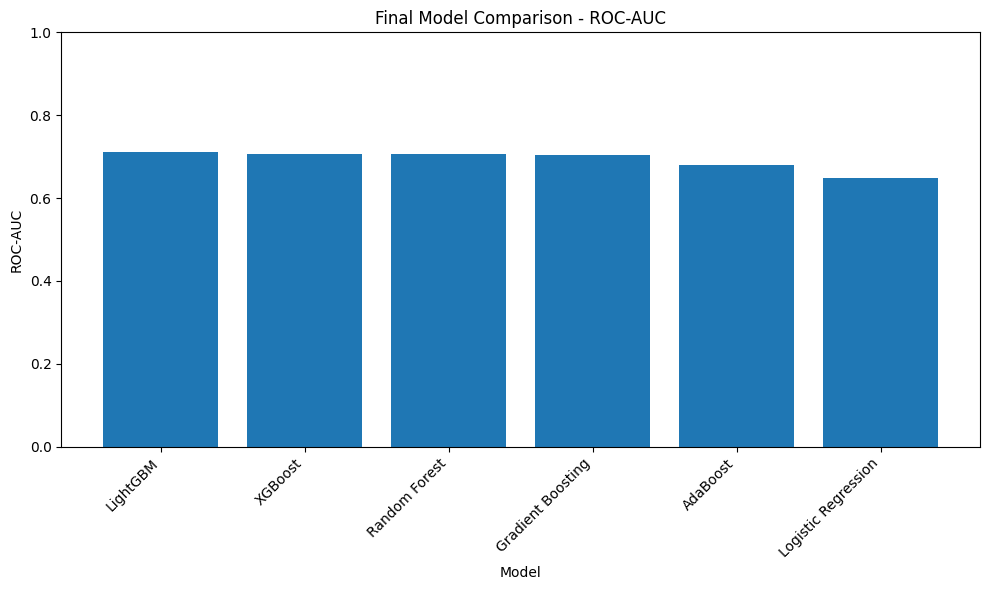

In [ ]:
# ROC-AUC comparison

plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["ROC-AUC"]
)

plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.title("Final Model Comparison - ROC-AUC")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

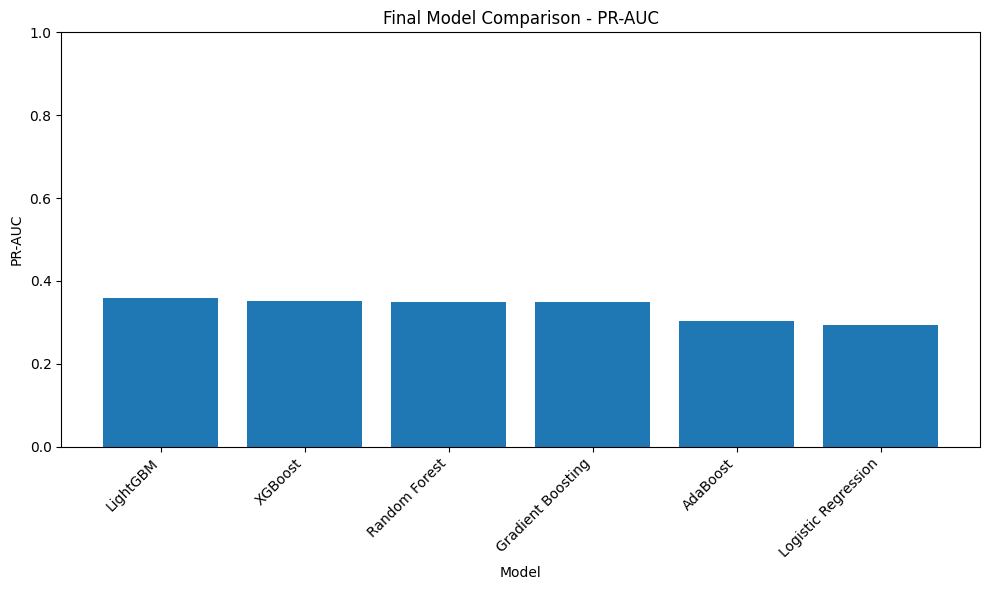

In [ ]:
# PR-AUC comparison

plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["PR-AUC"]
)

plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.title("Final Model Comparison - PR-AUC")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

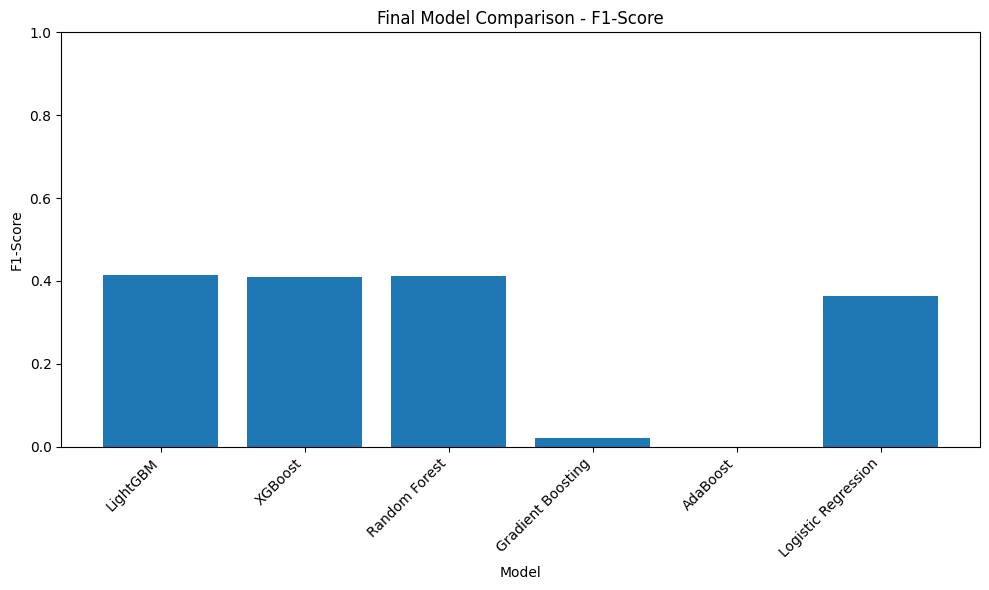

In [ ]:
# F1-score comparison

plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison["Model"],
    final_comparison["F1-Score"]
)

plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.title("Final Model Comparison - F1-Score")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Evaluation imports

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


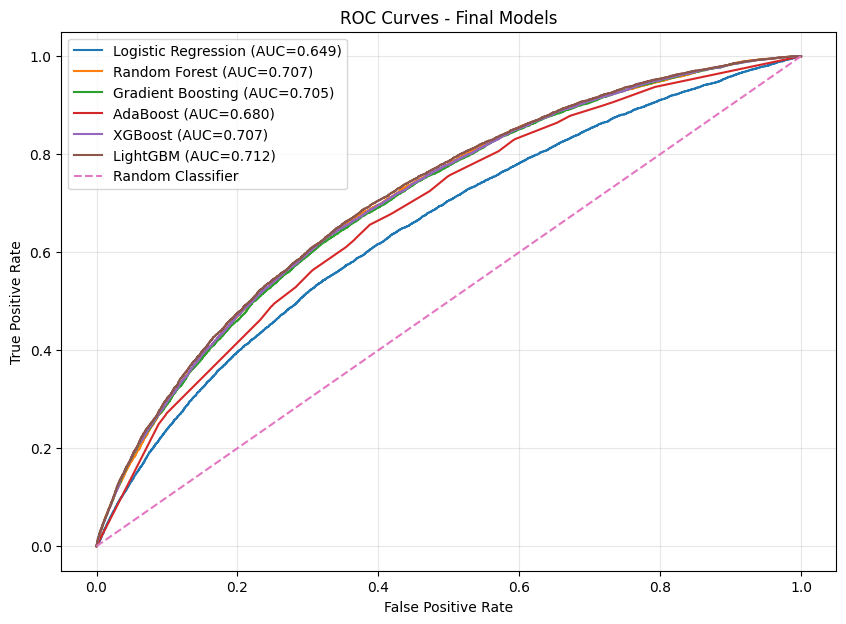

In [ ]:
# ROC curves for all final models

plt.figure(figsize=(10, 7))

for model_name, model in final_models.items():

    y_prob = model.predict_proba(X_test5)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test5,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test5,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Final Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

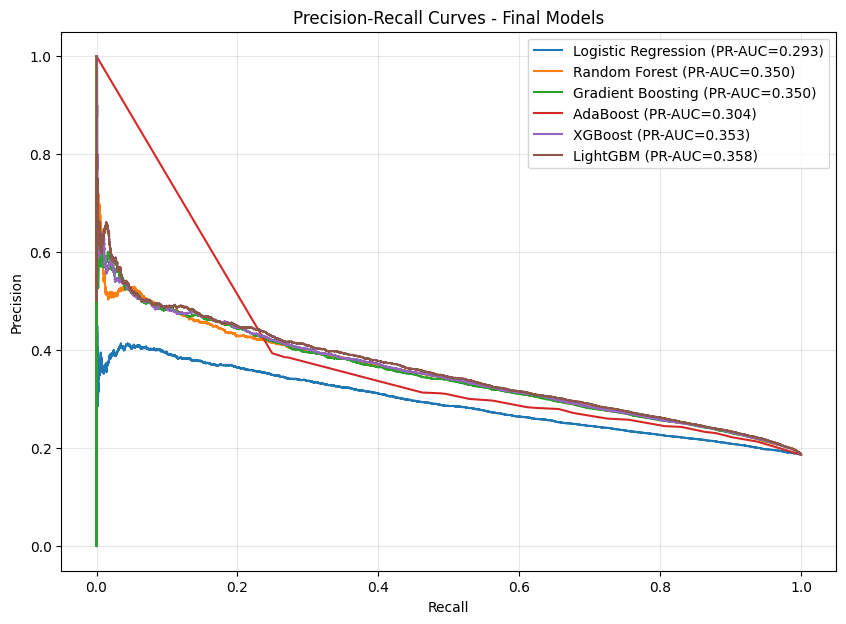

In [ ]:
# Precision-Recall curves

plt.figure(figsize=(10, 7))

for model_name, model in final_models.items():

    y_prob = model.predict_proba(X_test5)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test5,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test5,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Final Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

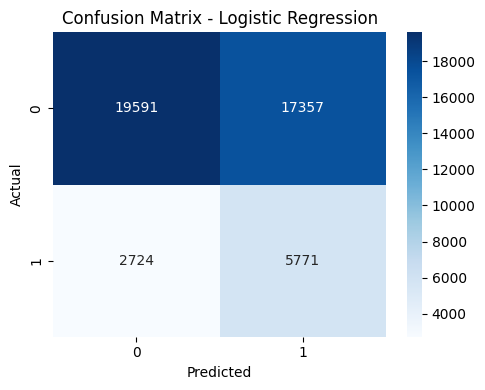

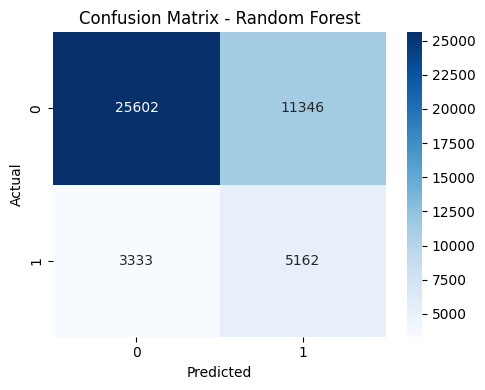

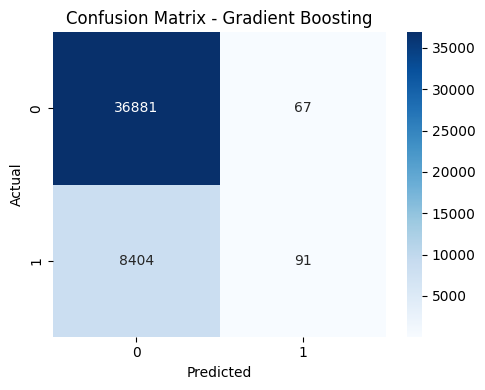

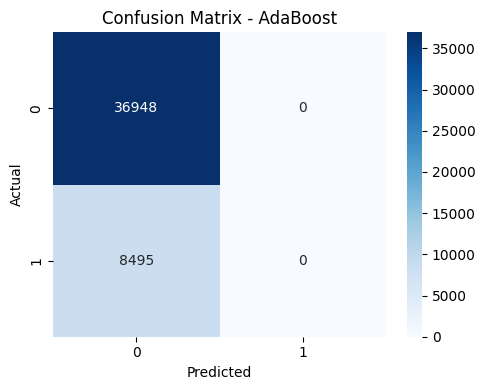

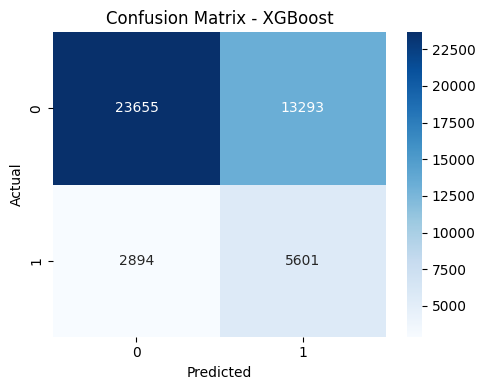

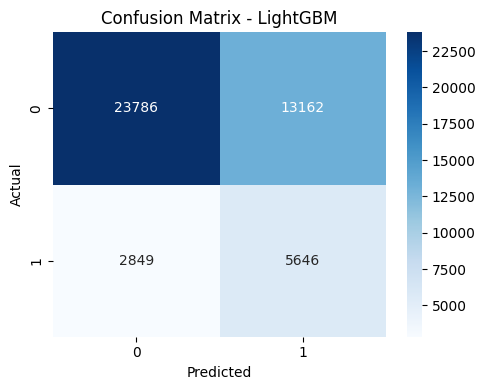

In [ ]:
# Confusion matrices for final models

for model_name, model in final_models.items():

    y_pred = model.predict(X_test5)

    cm = confusion_matrix(
        y_test5,
        y_pred
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [ ]:
# Classification reports

for model_name, model in final_models.items():

    y_pred = model.predict(X_test5)

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test5,
            y_pred,
            target_names=[
                "Fully Paid",
                "Default"
            ],
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  Fully Paid       0.88      0.53      0.66     36948
     Default       0.25      0.68      0.36      8495

    accuracy                           0.56     45443
   macro avg       0.56      0.60      0.51     45443
weighted avg       0.76      0.56      0.61     45443

Random Forest
              precision    recall  f1-score   support

  Fully Paid       0.88      0.69      0.78     36948
     Default       0.31      0.61      0.41      8495

    accuracy                           0.68     45443
   macro avg       0.60      0.65      0.60     45443
weighted avg       0.78      0.68      0.71     45443

Gradient Boosting
              precision    recall  f1-score   support

  Fully Paid       0.81      1.00      0.90     36948
     Default       0.58      0.01      0.02      8495

    accuracy                           0.81     45443
   macro avg       0.70      0.50      0.46     45443
weighted avg       0.7

## Final Hyperparameter Configuration

For computational efficiency, the final models use compact configurations.

| Model | Important Parameters |
|---|---|
| Logistic Regression | class_weight = balanced, max_iter = 500 |
| Random Forest | n_estimators = 100, max_depth = 15 |
| Gradient Boosting | n_estimators = 75, max_depth = 2 |
| AdaBoost | n_estimators = 75, learning_rate = 0.05 |
| XGBoost | n_estimators = 75, max_depth = 3, tree_method = hist |
| LightGBM | n_estimators = 75, num_leaves = 15, max_depth = 6 |

The configurations were selected to provide a practical balance between model complexity and computational cost for the large LendingClub dataset.

In [ ]:
# Get transformed feature names from the existing preprocessing pipeline

feature_names = preprocessor5.get_feature_names_out()

print("Number of transformed features:", len(feature_names))

Number of transformed features: 875


In [ ]:
# Random Forest feature importance

rf_classifier = rf_final.named_steps["classifier"]

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance.head(20)

,Feature,Importance
4,num__int_rate,0.109769
32,cat__grade_A,0.049676
31,cat__term_ 60 months,0.044988
27,num__loan_income_ratio,0.043984
28,num__installment_income_ratio,0.043037
29,num__funded_income_ratio,0.042834
24,num__term_num,0.040221
30,cat__term_ 36 months,0.037662
7,num__dti,0.034654
26,num__log_annual_inc,0.032204


In [ ]:
# XGBoost feature importance

xgb_classifier = xgb_final.named_steps["classifier"]

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_classifier.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
33,cat__grade_B,0.289754
32,cat__grade_A,0.197707
31,cat__term_ 60 months,0.119695
4,num__int_rate,0.078662
24,num__term_num,0.047152
29,num__funded_income_ratio,0.033491
27,num__loan_income_ratio,0.026191
28,num__installment_income_ratio,0.021495
26,num__log_annual_inc,0.020369
6,num__annual_inc,0.019745


In [ ]:
# LightGBM feature importance

lgbm_classifier = lgbm_final.named_steps["classifier"]

lgbm_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lgbm_classifier.feature_importances_
})

lgbm_importance = lgbm_importance.sort_values(
    by="Importance",
    ascending=False
)

lgbm_importance.head(20)

,Feature,Importance
4,num__int_rate,175
6,num__annual_inc,118
7,num__dti,117
0,num__Unnamed: 0,65
27,num__loan_income_ratio,50
22,num__tot_cur_bal,48
196,cat__purpose_small_business,46
24,num__term_num,42
9,num__inq_last_6mths,37
29,num__funded_income_ratio,36


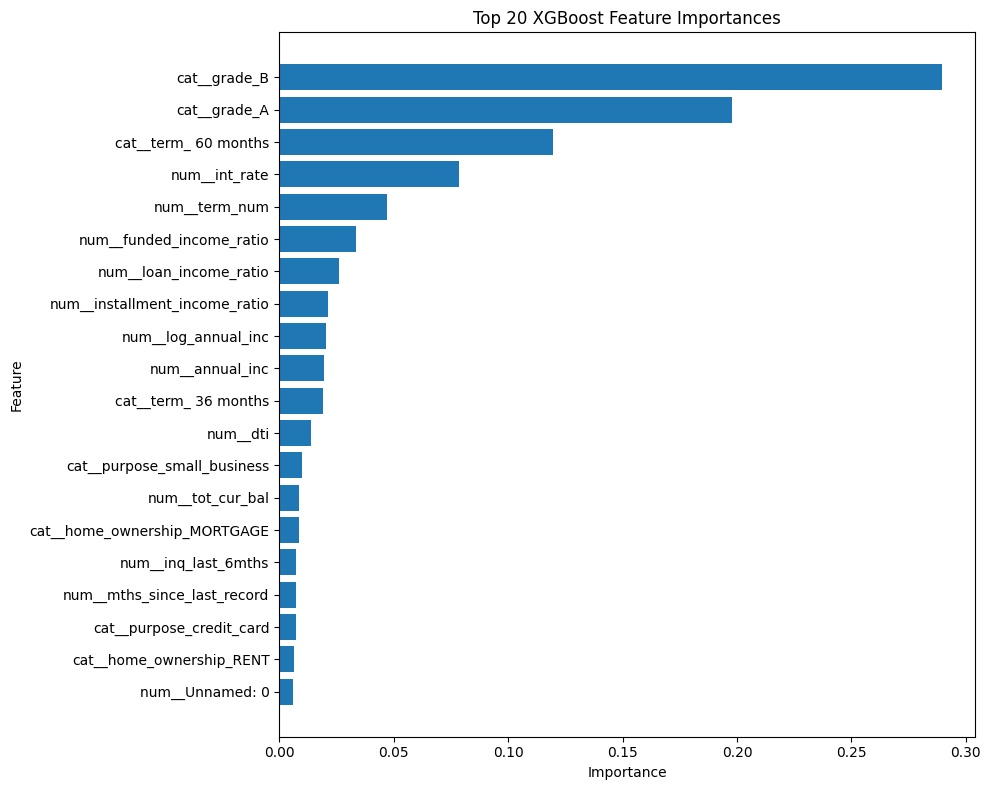

In [ ]:
# Top 20 XGBoost features

top_xgb = xgb_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_xgb["Feature"],
    top_xgb["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

In [ ]:
# Threshold analysis using the model with the highest ROC-AUC

best_model_name = final_comparison.iloc[0]["Model"]

best_model = final_models[best_model_name]

probabilities = best_model.predict_proba(
    X_test5
)[:, 1]

thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test5,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test5,
            predictions,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_test5,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.20,0.196277,0.991760,0.327700
1,0.25,0.204123,0.976810,0.337681
2,0.30,0.218112,0.948911,0.354696
3,0.35,0.234240,0.900177,0.371746
4,0.40,0.252651,0.832961,0.387705
5,0.45,0.274799,0.755268,0.402977
6,0.50,0.300191,0.664626,0.413581
7,0.55,0.326738,0.559859,0.412650
8,0.60,0.362053,0.447675,0.400337
9,0.65,0.398315,0.328311,0.359941


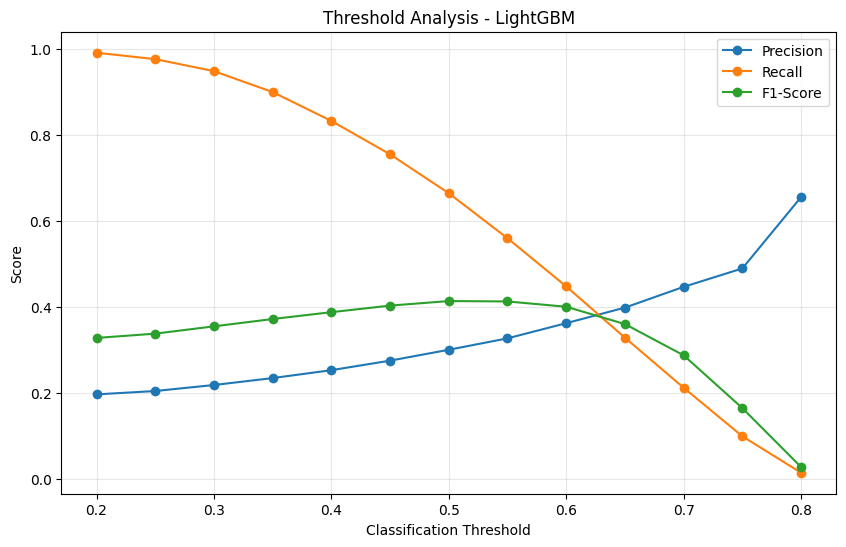

In [ ]:
# Threshold analysis plot

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    f"Threshold Analysis - {best_model_name}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Find threshold with highest F1-score

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

print("Model:", best_model_name)

print(
    "Best threshold:",
    round(best_threshold_row["Threshold"], 2)
)

print(
    "Precision:",
    round(best_threshold_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_threshold_row["Recall"], 4)
)

print(
    "F1-Score:",
    round(best_threshold_row["F1-Score"], 4)
)

Model: LightGBM
Best threshold: 0.5
Precision: 0.3002
Recall: 0.6646
F1-Score: 0.4136


In [ ]:
# Save final comparison results

final_comparison.to_csv(
    "week9_final_model_comparison.csv",
    index=False
)

threshold_df.to_csv(
    "week9_threshold_analysis.csv",
    index=False
)

print("Final Results saved successfully.")

Final Results saved successfully.


## Final Evaluation

The final models were evaluated using multiple performance measures.

Accuracy measures the overall proportion of correct predictions.

Precision measures the proportion of predicted defaults that were actually defaults.

Recall measures the proportion of actual defaults that were successfully identified by the model.

F1-Score provides a balance between precision and recall.

ROC-AUC measures the ability of the model to distinguish between default and non-default cases across classification thresholds.

PR-AUC provides additional insight into model performance for the minority/default class and is particularly relevant when the target classes are imbalanced.

The final comparison table generated above should be used to interpret the actual performance obtained from the LendingClub test dataset.

## Model Interpretation

The final comparison includes six machine learning approaches:

### Logistic Regression

Logistic Regression provides a relatively simple baseline and serves as a reference point for evaluating the more complex tree-based models.

### Random Forest

Random Forest combines multiple decision trees and can capture nonlinear relationships between borrower and loan characteristics.

### Gradient Boosting

Gradient Boosting builds trees sequentially, with each new tree attempting to improve the errors made by previous trees.

### AdaBoost

AdaBoost sequentially focuses on difficult observations and combines multiple weak learners into a stronger classifier.

### XGBoost

XGBoost uses gradient boosting with additional regularization and computational optimizations. The histogram-based tree method was used to improve training efficiency.

### LightGBM

LightGBM is another gradient boosting framework designed for efficient training on large datasets. It uses leaf-wise tree growth and can model nonlinear relationships efficiently.

The actual test-set results generated above provide the basis for comparing these models rather than relying on assumptions about which algorithm should perform best.

## Feature Importance Interpretation

Feature importance was examined for Random Forest, XGBoost, and LightGBM.

The feature importance tables identify variables that contributed strongly to the decision-making process of the respective tree-based models.

Because categorical variables were one-hot encoded, some original categorical variables may appear as multiple transformed features.

Feature importance should be interpreted as model-specific importance rather than as evidence that a variable independently causes loan default.

The top features generated in the previous cells can be examined to understand which borrower, loan, financial, and credit-history characteristics were most influential in the trained models.

# Final Conclusion

This project developed an end-to-end machine learning workflow for credit risk and loan default prediction using the LendingClub Loan Dataset.

The project began with data understanding, data quality assessment, exploratory data analysis, and identification of the target variable.

Feature engineering was then performed to create useful variables related to loan characteristics, borrower income, employment, loan affordability, issue date, and credit history.

Potential target leakage was addressed by excluding variables containing information generated after loan origination, such as repayment, recovery, and payment-related variables.

The prepared data was used to train a Logistic Regression baseline and five tree-based machine learning models: Random Forest, Gradient Boosting, AdaBoost, XGBoost, and LightGBM.

The models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC.

ROC curves, Precision-Recall curves, confusion matrices, and feature importance analysis were used to provide a broader understanding of model performance.

Threshold analysis was also conducted to demonstrate how changing the classification threshold affects precision, recall, and F1-score.

The final model comparison table generated from the test dataset should be used as the primary evidence for comparing the models. The analysis avoids relying only on accuracy because the default class is imbalanced and identifying default cases is an important part of the problem.

Overall, the project demonstrates a complete machine learning pipeline for credit risk modelling, including data preprocessing, exploratory analysis, feature engineering, model development, evaluation, tuning, comparison, and interpretation.

# Final Submission Checklist

The completed project contains:

- [x] Problem Statement
- [x] Dataset Description
- [x] Proposed Workflow
- [x] Baseline Model
- [x] Evaluation Metrics
- [x] Preprocessing
- [x] Exploratory Data Analysis
- [x] Feature Engineering
- [x] Logistic Regression
- [x] Random Forest
- [x] Gradient Boosting
- [x] AdaBoost
- [x] XGBoost
- [x] LightGBM
- [x] Initial Model Comparison
- [x] Preliminary Hyperparameter Tuning
- [x] Final Model Training
- [x] Final Model Comparison
- [x] ROC-AUC Analysis
- [x] Precision-Recall Analysis
- [x] Confusion Matrix Analysis
- [x] Feature Importance
- [x] Threshold Analysis
- [x] Model Interpretation
- [x] Limitations
- [x] Future Work
- [x] Final Conclusion

# References

1. Kaggle. *LendingClub Loan Dataset*. Dataset used for credit risk and loan default prediction.
   https://www.kaggle.com/datasets/habiburrohman/lendingclub-loan-dataset

2. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.
   https://scikit-learn.org/

3. Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.
   https://xgboost.readthedocs.io/

4. Ke, G., Meng, Q., Finley, T., et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. Advances in Neural Information Processing Systems, 30.
   https://lightgbm.readthedocs.io/

5. Breiman, L. (2001). *Random Forests*. Machine Learning, 45, 5–32.
   https://doi.org/10.1023/A:1010933404324

6. Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. The Annals of Statistics, 29(5), 1189–1232.
   https://doi.org/10.1214/aos/1013203451

7. Freund, Y., & Schapire, R. E. (1997). *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*. Journal of Computer and System Sciences, 55(1), 119–139.
   https://doi.org/10.1006/jcss.1997.1504

8. Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.

9. Jupyter Project. *Jupyter Notebook Documentation*.
   https://jupyter.org/documentation

10. Python Software Foundation. *Python Documentation*.
    https://docs.python.org/3/